In [1]:
import pandas as pd
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
import seaborn as sns
import xarray as xr
import glob
from pathlib import Path
from tqdm import tqdm
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import mannkendall as mk
from datetime import datetime
from scipy import stats as st
from matplotlib.lines import Line2D
from plots import *
import warnings
warnings.filterwarnings("ignore")
import os.path
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from windrose import WindroseAxes
from matplotlib.ticker import FuncFormatter
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import pyproj
from ast import literal_eval
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as clrs

# Get the most frequent grid_mapping

In [2]:
datadir = "/home/user/These/cordex_htws_cc3d/Data"

da_cell_area = xr.open_dataset(join(datadir,'cellarea',f'gridarea_CORDEX_EUR11_ERA5.nc'),engine='netcdf4').cell_area
da_mask = xr.open_dataset(join(datadir,'mask',f'mask_Europe_land_only_CORDEX_EUR11_ERA5.nc'),engine='netcdf4').mask
area_Europe = (da_cell_area * (da_mask.data==0)).sum().data/1e6 # compute the area of studied part of Europe in km²

dict_volume_Europe = {'noleap': area_Europe*92, '360_day':area_Europe*90}

print(area_Europe, 'km²')
print(dict_volume_Europe)


8576798.281197237 km²
{'noleap': np.float64(789065441.8701458), '360_day': np.float64(771911845.3077513)}


In [3]:
df_htws = pd.read_csv(join(datadir,'df_global_htws.csv'),header=0,index_col=0)
df_global_summers = pd.read_csv(join(datadir,'df_global_summers.csv'),header=0,index_col=0)


In [4]:
df_htws['Relative spatial extent (%)'] = None
df_htws['Relative mean spatial extent (%)'] = None
df_htws['Relative accumulated area (%)'] = None
for i in tqdm(df_htws.index):
    calendar = df_htws.loc[i,'calendar']
    df_htws.loc[i,'Relative spatial extent (%)'] = 100*df_htws.loc[i,'Spatial extent']/area_Europe
    df_htws.loc[i,'Relative mean spatial extent (%)'] = 100*df_htws.loc[i,'Mean spatial extent']/area_Europe
    df_htws.loc[i,'Relative accumulated area (%)'] = 100*df_htws.loc[i,'Accumulated area']/dict_volume_Europe[calendar]


df_global_summers['JJA duration'] = None
df_global_summers['Relative accumulated area summer (%)'] = None
for i in tqdm(df_global_summers.index):
    calendar = df_global_summers.loc[i,'calendar']
    df_global_summers.loc[i,'JJA duration'] = 90 if calendar=='360_day' else 92
    df_global_summers.loc[i,'Relative accumulated area summer (%)'] = 100*df_global_summers.loc[i,'Accumulated area summer']/dict_volume_Europe[calendar]

100%|██████████| 4551/4551 [00:02<00:00, 2172.18it/s]


In [5]:

split_year_population = 2025

df_htws['Exposed_population_ssp1_all_period'] = None
df_htws['HWMId_pop_ssp1_all_period'] = None
df_htws['Exposed_population_ssp2_all_period'] = None
df_htws['HWMId_pop_ssp2_all_period'] = None
df_htws['Exposed_population_ssp3_all_period'] = None
df_htws['HWMId_pop_ssp3_all_period'] = None
df_htws['Exposed_population_ssp4_all_period'] = None
df_htws['HWMId_pop_ssp4_all_period'] = None
df_htws['Exposed_population_ssp5_all_period'] = None
df_htws['HWMId_pop_ssp5_all_period'] = None

df_htws['Total_exposed_population_ssp1_all_period'] = None
df_htws['Total_exposed_population_ssp2_all_period'] = None
df_htws['Total_exposed_population_ssp3_all_period'] = None
df_htws['Total_exposed_population_ssp4_all_period'] = None
df_htws['Total_exposed_population_ssp5_all_period'] = None

for i in tqdm(df_htws.index):
    year = df_htws.loc[i,'Year']
    for ssp in range (1,6):
        if year <= split_year_population:
            df_htws.loc[i,f'Exposed_population_ssp{ssp}_all_period'] = df_htws.loc[i,f'Exposed_population_ghs']
            df_htws.loc[i,f'Total_exposed_population_ssp{ssp}_all_period'] = df_htws.loc[i,f'Total_exposed_population_ghs']
            df_htws.loc[i,f'HWMId_pop_ssp{ssp}_all_period'] = df_htws.loc[i,f'HWMId_pop_ghs']
        else:
            df_htws.loc[i,f'Exposed_population_ssp{ssp}_all_period'] = df_htws.loc[i,f'Exposed_population_ssp{ssp}']
            df_htws.loc[i,f'Total_exposed_population_ssp{ssp}_all_period'] = df_htws.loc[i,f'Total_exposed_population_ssp{ssp}']
            df_htws.loc[i,f'HWMId_pop_ssp{ssp}_all_period'] = df_htws.loc[i,f'HWMId_pop_ssp{ssp}']

100%|██████████| 19733/19733 [01:05<00:00, 301.97it/s]


In [6]:
df_htws_BC = df_htws[df_htws['bias-adjusted']]
df_htws_unadjusted = df_htws[(df_htws['bias-adjusted']==False) & (df_htws['model']!='ERA5')]
df_htws_models = df_htws[df_htws['model']!='ERA5']
df_ERA5 = df_htws[df_htws['model']=='ERA5']

# Compare models to ERA5 for 1975-2025 period

In [7]:
df_htws_historical = df_htws_models[(df_htws_models['Year']>=1975) & (df_htws_models['Year']<=2025)]
sub_df = df_htws_historical[['Year', 'Start Date', 'End Date', 'model', 'Intensity', 'Spatial extent', 'Accumulated area', 'Duration',
       'Max', 'HWMId_sum', 'Exposed_population_ghs', 'HWMId_pop_ghs',
        'GCM', 'RCM', 'simulation', 'version', 'ensemble',
       'version_date', 'calendar', 'bias-adjusted', 'grid_mapping']]
df_ERA5 = df_htws[df_htws['model']=='ERA5']
df_ERA5 = df_ERA5[(df_ERA5['Year']>=1975) & (df_ERA5['Year']<=2025)]
sub_df = sub_df[sub_df['model']!='ERA5']
model_list = np.unique(sub_df['model'])

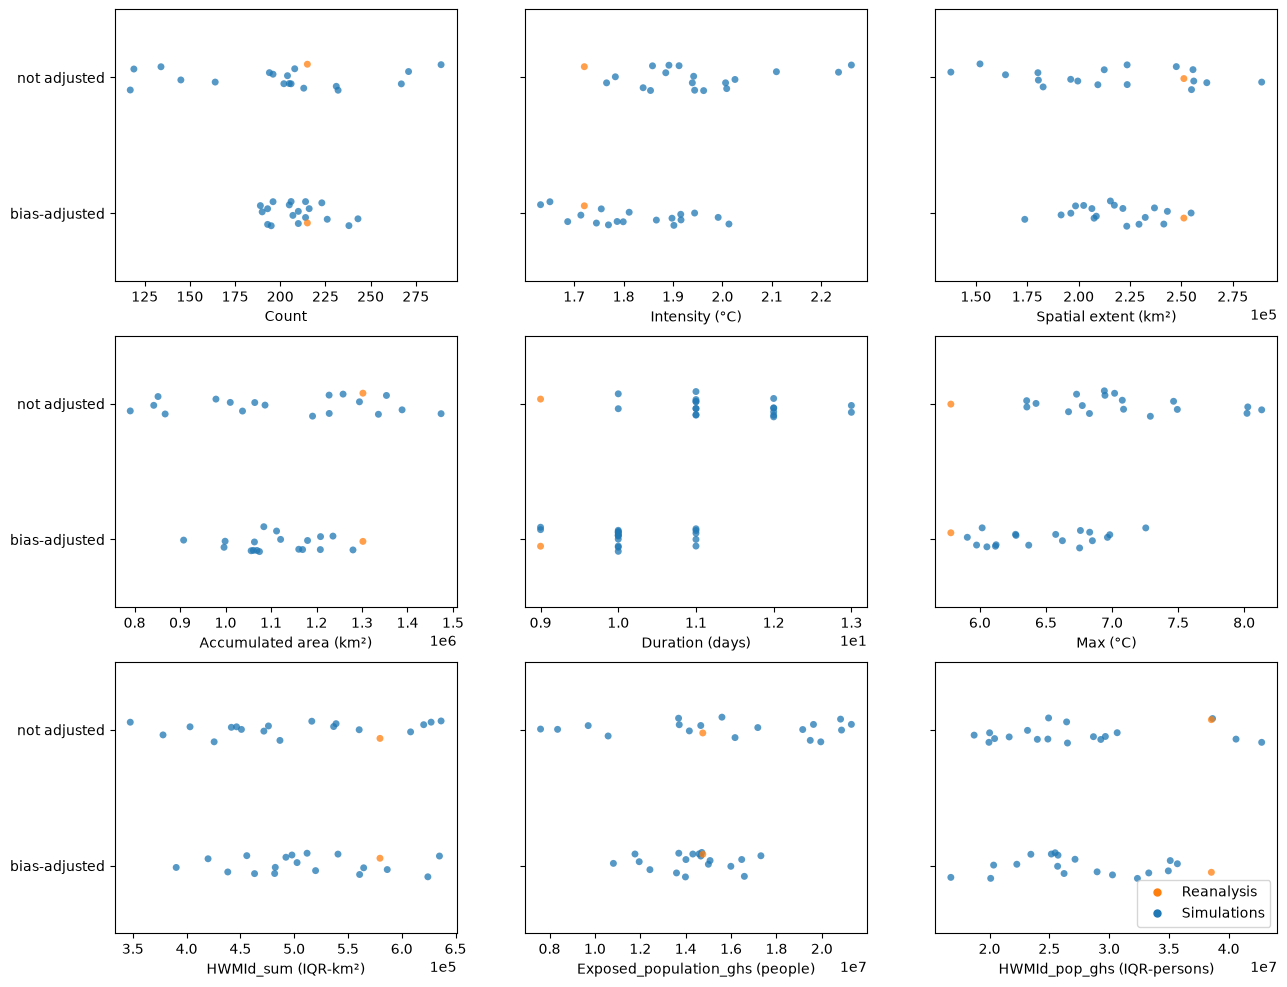

In [8]:
# Plot heatwaves count
fig,axes = plt.subplots(3,3,sharey=True,figsize=(15,12))
df_count = pd.DataFrame(columns=['model','Count','plot_category','type'])

unit_dict = {'Frequency':'','Nb hot days':'(days)','Accumulated area summer':'(km²)','Intensity':'(°C)','Spatial extent':'(km²)','Accumulated area':'(km²)',
'Duration':'(days)','Max':'(°C)','HWMId_sum':'(IQR-km²)','Exposed_population_ghs':'(people)','HWMId_pop_ghs':'(IQR-persons)'}

plot_category = ['not adjusted','bias-adjusted']
idx = 0
for model in model_list:
    sub_df_model = sub_df[sub_df['model']==model]
    htw_count = len(sub_df_model)

    if sub_df_model.iloc[0,:]['bias-adjusted'] == True:
        df_count.loc[idx,'model'] = model
        df_count.loc[idx,'Count'] = htw_count
        df_count.loc[idx,'plot_category'] = 'bias-adjusted'
        idx += 1
    else:
        df_count.loc[idx,'model'] = model
        df_count.loc[idx,'Count'] = htw_count
        df_count.loc[idx,'plot_category'] = 'not adjusted'
        idx += 1

df_count['type'] = 'simulation'
for cat in plot_category:
    df_count.loc[idx,'model']='ERA5'
    df_count.loc[idx,'Count'] = len(df_ERA5)
    df_count.loc[idx,'plot_category'] = cat
    df_count.loc[idx,'type'] = 'reanalysis'
    idx += 1

ax = axes[0][0]
handles, labels = sns.stripplot(data=df_count, x='Count',y='plot_category', ax=ax, hue='type',
order=['not adjusted','bias-adjusted'],
jitter=True,alpha=0.75,legend=False).get_legend_handles_labels()
ax.set_ylabel(None)
# Plot heatwaves count
for i,index in enumerate(['Intensity','Spatial extent','Accumulated area','Duration','Max','HWMId_sum',
    'Exposed_population_ghs','HWMId_pop_ghs']):
    df_count = pd.DataFrame(columns=['model',index,'plot_category','type'])
    idx = 0
    #if i>0:
    #    i+=1
    for model in model_list:
        sub_df_model = sub_df[sub_df['model']==model]
        htw_count = np.nanmedian(sub_df_model[index].tolist())

        df_count.loc[idx,'model'] = model
        df_count.loc[idx,index] = htw_count
        df_count.loc[idx,'plot_category'] = 'all'
        idx += 1

        if sub_df_model.iloc[0,:]['bias-adjusted'] == True:
            df_count.loc[idx,'model'] = model
            df_count.loc[idx,index] = htw_count
            df_count.loc[idx,'plot_category'] = 'bias-adjusted'
            idx += 1
        else:
            df_count.loc[idx,'model'] = model
            df_count.loc[idx,index] = htw_count
            df_count.loc[idx,'plot_category'] = 'not adjusted'
            idx += 1

    df_count['type'] = 'simulation'
    for cat in plot_category:
        df_count.loc[idx,'model']='ERA5'
        df_count.loc[idx,index] = np.nanmedian(df_ERA5[index].tolist())
        df_count.loc[idx,'plot_category'] = cat
        df_count.loc[idx,'type'] = 'reanalysis'
        idx += 1
    ax = axes[(i+1)//3][(i+1)%3]
    sns.stripplot(data=df_count, x=index,y='plot_category',hue='type',order=['not adjusted','bias-adjusted'],
    jitter=True,alpha=0.75,log_scale=False,ax=ax,legend=False)
    ax.set_xlabel(f'{index} {unit_dict[index]}')
    ax.set_ylabel(None)
    ax.ticklabel_format(style='scientific', axis='x', scilimits=(0, 0))
    #ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter(useMathText=True))

ax=axes[-1][-1]
#ax.axis("off")

colors = mpl.colormaps['tab10'].colors
point_1 = Line2D([0], [0], label='Reanalysis', marker='o', markersize=5, 
         markeredgecolor=colors[1], markerfacecolor=colors[1], linestyle='')
point_2 = Line2D([0], [0], label='Simulations', marker='o', markersize=5, markeredgecolor=colors[0], markerfacecolor=colors[0], linestyle='')

ax.legend(handles=[point_1,point_2],loc='lower right')

plt.savefig(join(datadir,'figs',f'compare_htws_count_median_1975_2025.pdf'),dpi=1200)
plt.savefig(join(datadir,'figs',f'compare_htws_count_median_1975_2025.png'))
plt.show()
plt.close()


In [9]:
#df_ERA5['HWMId_sum'] = df_ERA5['HWMId_sum'].replace(0, np.nan)
#df_ERA5['HWMId_pop_ghs'] = df_ERA5['HWMId_pop_ghs'].replace(0, np.nan)
#df_htws['HWMId_sum'] = df_htws['HWMId_sum'].replace(0, np.nan)
#df_htws['HWMId_pop_ghs'] = df_htws['HWMId_pop_ghs'].replace(0, np.nan)

# Cramer - von Mises tests

In [10]:
df_htws_historical = df_htws_models[(df_htws_models['Year']>=1975) & (df_htws_models['Year']<=2025)]
sub_df = df_htws_historical[['Year', 'Start Date', 'End Date', 'model', 'Intensity', 'Spatial extent', 'Accumulated area', 'Duration',
       'Max', 'HWMId_sum', 'Exposed_population_ghs', 'HWMId_pop_ghs',
        'GCM', 'RCM', 'simulation', 'version', 'ensemble',
       'version_date', 'calendar', 'bias-adjusted', 'grid_mapping']]
df_ERA5 = df_htws[df_htws['model']=='ERA5']
df_ERA5 = df_ERA5[(df_ERA5['Year']>=1975) & (df_ERA5['Year']<=2025)]
sub_df = sub_df[sub_df['model']!='ERA5']
model_list = np.unique(sub_df['model'])

In [11]:
# For all models, not grouped
iterables = [
    ['Intensity', 'Spatial extent', 'Accumulated area', 'Duration','Max', 'HWMId_sum', 'Exposed_population_ghs', 'HWMId_pop_ghs'],
    ['statistic','pvalue']#,'statistic_location','statistic_sign']
    ]

df_cvm = pd.DataFrame(index=model_list,columns=pd.MultiIndex.from_product(iterables, names=["index", "cvm"]),dtype=float)

index_list = ['Intensity', 'Spatial extent', 'Accumulated area', 'Duration', 'Max', 'HWMId_sum', 'Exposed_population_ghs', 'HWMId_pop_ghs']
stat_list = ['statistic','pvalue']#,'statistic_location','statistic_sign']
for model in df_cvm.index:
    sub_df_model = sub_df[sub_df['model']==model]
    for index in index_list:
        res = st.cramervonmises_2samp(df_ERA5[index].to_list(),sub_df_model[index].to_list(),nan_policy='omit')
        for stat in stat_list:
            df_cvm.loc[model,(index,stat)] = getattr(res,stat)

In [12]:
df_pvalue = df_cvm.xs('pvalue', axis=1, level=1, drop_level=False)
(df_pvalue>0.05).sum()

index                   cvm   
Intensity               pvalue    13
Spatial extent          pvalue    24
Accumulated area        pvalue    31
Duration                pvalue     8
Max                     pvalue     3
HWMId_sum               pvalue    24
Exposed_population_ghs  pvalue    29
HWMId_pop_ghs           pvalue    27
dtype: int64

In [13]:
model_name_dict = {
    'CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'A45',
    'CLMcom_MOHC-HadGEM2-ES_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'A85',
    'CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'B45',
    'CLMcom_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'B85',
    'CNRM_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'D45',
    'CNRM_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'D85',
    'CNRM_MOHC-HadGEM2-ES_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'C85',
    'DMI_NCC-NorESM1-M_rcp45_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'E45',
    'DMI_NCC-NorESM1-M_rcp85_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'E85',
    'GERICS_NCC-NorESM1-M_rcp45_r1i1p1_GERICS-REMO2015_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'F45',
    'GERICS_NCC-NorESM1-M_rcp85_r1i1p1_GERICS-REMO2015_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'F85',
    'ICTP_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_ICTP-RegCM4-6_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'G85',
    'KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'H45',
    'KNMI_ICHEC-EC-EARTH_rcp85_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'H85',
    'MOHC_ICHEC-EC-EARTH_rcp85_r12i1p1_MOHC-HadREM3-GA7-05_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'I85',
    'MPI-CSC_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_MPI-CSC-REMO2009_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'J45',
    'MPI-CSC_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_MPI-CSC-REMO2009_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'J85',
    'SMHI_ICHEC-EC-EARTH_rcp85_r1i1p1_SMHI-RCA4_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'K85',
    }

In [14]:
df_table = (df_pvalue[df_pvalue.index.isin(df_htws_BC['model'])]>0.05)
df_table['Sum'] = None
df_table['Sum'] = (df_pvalue[df_pvalue.index.isin(df_htws_BC['model'])]>0.05).sum(axis=1)
df_table['Name'] = None
for model in df_table .index:
    df_table.loc[model,'Name'] = model_name_dict[model]
df_table

index,Intensity,Spatial extent,Accumulated area,Duration,Max,HWMId_sum,Exposed_population_ghs,HWMId_pop_ghs,Sum,Name
cvm,pvalue,pvalue,pvalue,pvalue,pvalue,pvalue,pvalue,pvalue,,
CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,True,True,True,False,True,True,True,True,7,A45
CLMcom_MOHC-HadGEM2-ES_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,True,True,True,False,True,True,True,True,7,A85
CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,False,True,True,True,False,True,True,True,6,B45
CLMcom_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,False,True,True,True,False,False,True,False,4,B85
CNRM_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,True,False,True,True,False,False,True,True,5,D45
CNRM_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,True,True,True,True,True,True,True,True,8,D85
CNRM_MOHC-HadGEM2-ES_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,True,True,True,False,False,True,True,True,6,C85
DMI_NCC-NorESM1-M_rcp45_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,False,False,True,False,False,False,True,False,2,E45
DMI_NCC-NorESM1-M_rcp85_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,False,True,True,False,False,True,True,True,5,E85


In [15]:
model_list_BC_results = df_table[df_table['Sum']>=6].index
model_list_BC_results

Index(['CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CLMcom_MOHC-HadGEM2-ES_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CNRM_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CNRM_MOHC-HadGEM2-ES_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'ICTP_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_ICTP-RegCM4-6_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'KNMI_ICHEC-EC-EARTH_rcp85_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'SMHI_ICHEC-EC-EARTH_rcp85_r1i1p1_SMHI-RCA4_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20

8it [00:00,  8.22it/s]


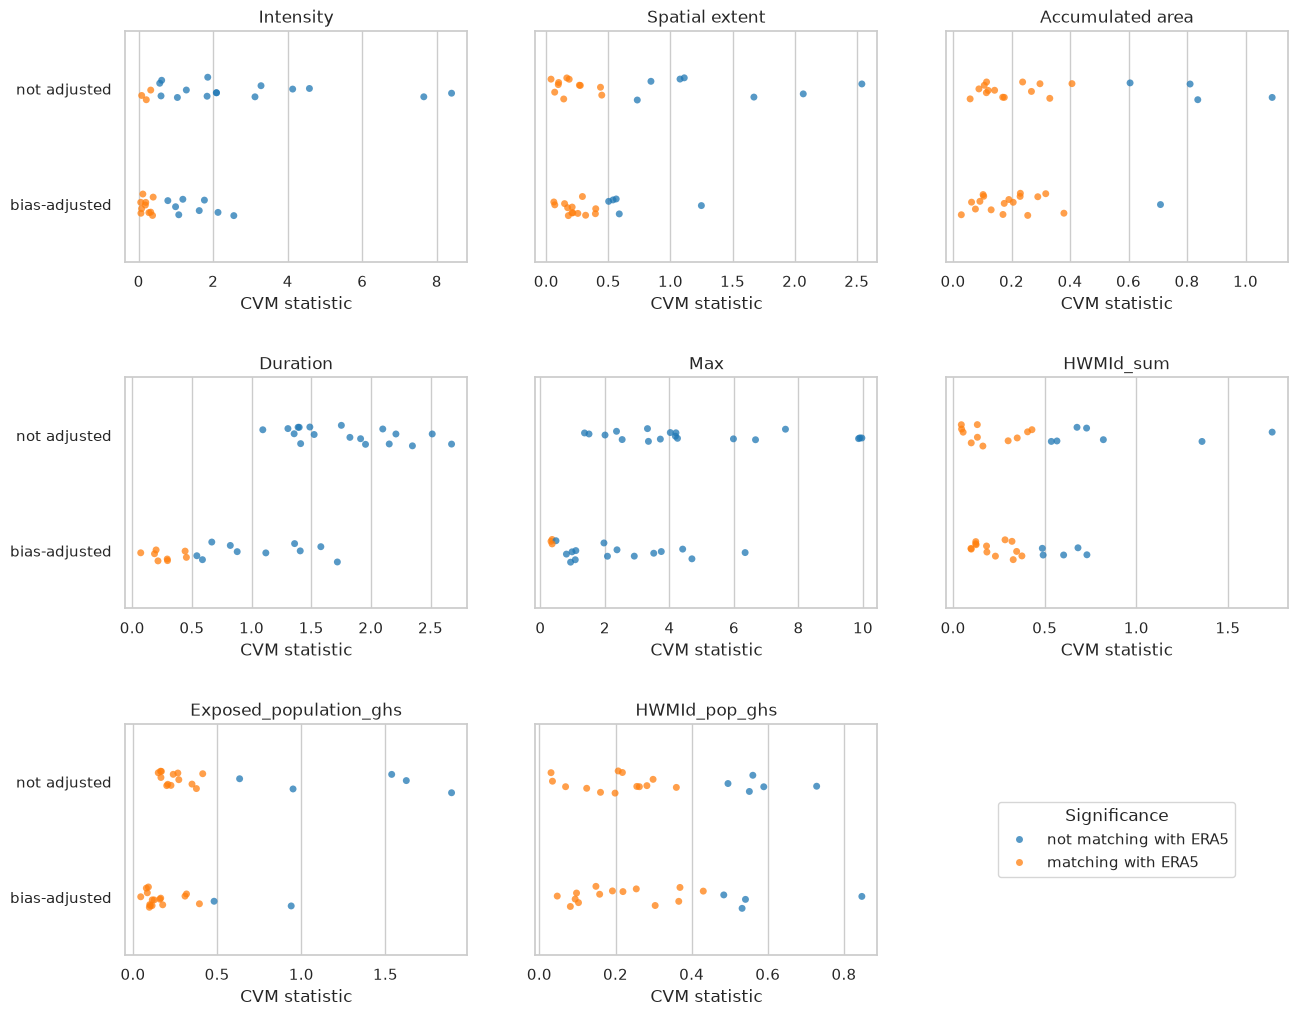

In [16]:
index_list = ['Intensity', 'Spatial extent', 'Accumulated area', 
'Duration','Max', 'HWMId_sum', 'Exposed_population_ghs', 'HWMId_pop_ghs']
plot_category = ['not adjusted','bias-adjusted']
sns.set_theme(style="whitegrid")
for i,index in tqdm(enumerate(index_list)):
    df_cvm_plot = pd.DataFrame(columns=['model','CVM statistic','plot_category','goodness of fit'])
    idx = 0
    for model in model_list:
        sub_df_model = sub_df[sub_df['model']==model]
        cvm_stat = df_cvm.loc[model,(index,'statistic')]

        if df_cvm.loc[model,(index,'pvalue')] > 0.05:
            sig = 'matching with ERA5'
        else:
            sig = 'not matching with ERA5'

        if 'Adjust' in model:
            df_cvm_plot.loc[idx,'model'] = model
            df_cvm_plot.loc[idx,'CVM statistic'] = cvm_stat
            df_cvm_plot.loc[idx,'plot_category'] = 'bias-adjusted'
            df_cvm_plot.loc[idx,'goodness of fit'] = sig
            idx += 1
        else:
            df_cvm_plot.loc[idx,'model'] = model
            df_cvm_plot.loc[idx,'CVM statistic'] = cvm_stat
            df_cvm_plot.loc[idx,'plot_category'] = 'not adjusted'
            df_cvm_plot.loc[idx,'goodness of fit'] = sig
            idx += 1
    
    if i==0:
        handles, labels = sns.stripplot(data=df_cvm_plot, x='CVM statistic',y='plot_category',hue='goodness of fit',order=['not adjusted','bias-adjusted'],
        hue_order=['not matching with ERA5','matching with ERA5'],jitter=True,alpha=0.75,palette='tab10').get_legend_handles_labels()
        plt.close()
        fig,axes = plt.subplots(3,3,figsize=(15, 12), sharex=False, sharey=True, gridspec_kw={"hspace": 0.5})
    ax=axes[i//3][i%3]
    sns.stripplot(data=df_cvm_plot, x='CVM statistic',y='plot_category',hue='goodness of fit',order=['not adjusted','bias-adjusted'],
    hue_order=['not matching with ERA5','matching with ERA5'],jitter=True,alpha=0.75,ax=ax,legend=False,palette='tab10')
    ax.set_title(index)
    ax.set_ylabel('')
ax=axes[-1][-1]
ax.axis("off")
plt.legend(handles, labels, loc='center',title='Significance')#loc=(0.1,0.625)
plt.savefig(join(datadir,'figs','cvm_test_all.pdf'),dpi=1200)
plt.savefig(join(datadir,'figs','cvm_test_all.png'))
plt.show()

In [17]:
df_htws_BC_results = df_htws[(df_htws['model'].isin(model_list_BC_results)) | (df_htws['model']=='ERA5')]
df_global_summers_results = df_global_summers[(df_global_summers['model'].isin(model_list_BC_results)) | (df_global_summers['model']=='ERA5')]
df_htws_BC_results.to_csv(join(datadir,'df_htws_BC_results.csv'))
df_global_summers_results.to_csv(join(datadir,'df_global_summers_results.csv'))

In [18]:
np.unique(df_htws_BC_results['model'])

array(['CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CLMcom_MOHC-HadGEM2-ES_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CNRM_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CNRM_MOHC-HadGEM2-ES_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'ERA5',
       'ICTP_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_ICTP-RegCM4-6_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'KNMI_ICHEC-EC-EARTH_rcp85_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'SMHI_ICHEC-EC-EARTH_rcp85_r1i1p1_SMHI-RCA4_SBCK-CDFt-ERA5-1976-2005_day_t

# Load aerosols information

In [19]:
df_aerosols = pd.read_csv(join(datadir,'cordex_aerosols_info.csv'),header=0,index_col=0)

In [20]:
df_aerosols

,aerosol_type,note
model,,
CLMcom-CCLM4-8-17,CAS,No seasonal cycle and no trends (Gutierrez 2020)
CLMcom-ETH-COSMO-crCLIM-v1-1,EAS,Monthly mean values for the base year 2000 (Gu...
CNRM-ALADIN63,EAS,Seasonal cycle for each class and trend for SU...
DMI-HIRHAM5,CAS,No temporal evolution (Gutierrez 2020)
GERICS-REMO2015,CAS,No seasonal cycle and no trends (Gutierrez 2020)
ICTP-RegCM4-6,CAS,Aerosols are not included (Gutierrez 2020)
IPSL-WRF381P,CAS,Constant in time (Gutierrez 2020)
KNMI-RACMO22E,EAS,Monthly variations and decadal trends (Gutierr...
MOHC-HadREM3-GA7-05,EAS,No information so we follow Belin et al (2026)


# Compute years with heatwaves all summer (even without 92-day-long heatwaves)

In [ ]:
df_global_summers = pd.read_csv(join(datadir,'df_global_summers.csv'),header=0,index_col=0)

model_list = np.unique(df_htws_models['model'])
print(len(model_list), "models")
df_global_summers['JJA duration'] = None
for i in df_global_summers.index:
    calendar = df_global_summers.loc[i,'calendar']
    df_global_summers.loc[i,'JJA duration'] = 90 if calendar=='360_day' else 92
#df_global_summers = df_global_summers[df_global_summers['model'].isin(model_list)]

df_92_days = df_global_summers[df_global_summers['Nb hot days']>=df_global_summers['JJA duration']]
print(len(np.unique(df_92_days['model'])), "models with heatwaves all summer")

33 models
34 models with heatwaves all summer


In [ ]:
dates_df = pd.DataFrame(index = model_list, columns=['Year of stable fully hot summer','First year of fully hot summer','bias-adjusted'], data=None)
for model in tqdm(model_list):
    JJA_duration = df_global_summers[df_global_summers['model']==model]['JJA duration'].iloc[0]
    stable_long_heatwave_year = 2100
    first_92_heatwave_year = 2100
    if model in df_92_days['model'].to_list():
        sub_df = df_global_summers[df_global_summers['model']==model]
        year = 2099
        period_start = 1975
        while year>=period_start:
            sub_df_year = sub_df[sub_df['Year']==year]
            if sub_df_year.size > 0 and sub_df_year['Nb hot days'].values < JJA_duration:
                break
            year = year - 1
        stable_long_heatwave_year = year + 1 # The first year with consistent occurrence of 92-day-long heatwaves is year+1 if there is no 92-day-long heatwave on year
        
        year = 1975
        period_end = 2099
        while year<=period_end:
            sub_df_year = sub_df[sub_df['Year']==year]
            if sub_df_year.size > 0 and sub_df_year['Nb hot days'].values >= JJA_duration:
                break
            year = year + 1
        first_92_heatwave_year = year # The first year with consistent occurrence of 92-day-long heatwaves is year+1 if there is no 92-day-long heatwave on year

    dates_df.loc[model,'bias-adjusted'] = 'Adjust' in model # 'Adjust' in model   
    dates_df.loc[model,'First year of fully hot summer'] = first_92_heatwave_year
    dates_df.loc[model,'Year of stable fully hot summer'] = stable_long_heatwave_year

print(f'There are {len(dates_df[dates_df['Year of stable fully hot summer']==2100])} models which never reach a level always showing a fully hot summer.')
print(f'There are {len(dates_df[dates_df['First year of fully hot summer']==2100])} models which never show any fully hot summer.')

100%|██████████| 18/18 [00:00<00:00, 21.08it/s]

There are 1 models which never reach a level always showing a fully hot summer.
There are 0 models which never show any fully hot summer.


In [12]:
dates_df#[dates_df['Year of stable fully hot summer']==2100]

NameError: name 'dates_df' is not defined

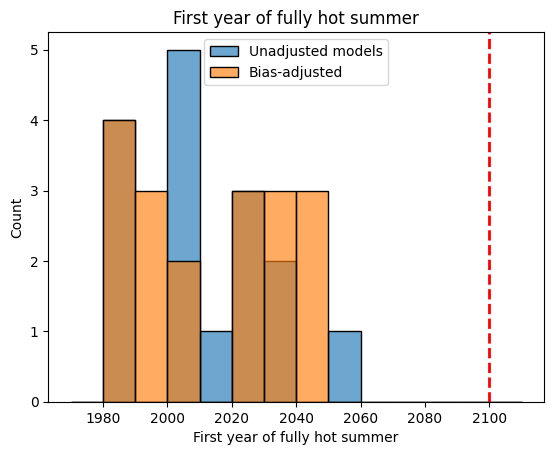

In [106]:
fig,ax = plt.subplots(1,1)
bins = np.arange(1970,2120,10)
sns.histplot(dates_df[dates_df['bias-adjusted']==False]['First year of fully hot summer'], ax=ax, alpha = 0.65,label='Unadjusted models',bins=bins) # plot years of reaching of consistent occurrence of 92-day-long heatwaves 
sns.histplot(dates_df[dates_df['bias-adjusted']==True]['First year of fully hot summer'],ax=ax,alpha=0.65,label='Bias-adjusted',bins=bins)
plt.axvline(x=2100,linewidth=2,linestyle='--',color='red')
plt.legend()
plt.title('First year of fully hot summer')
plt.savefig(join(datadir,'figs','first_year_fully_hot_summer.pdf'),dpi=1200)
plt.savefig(join(datadir,'figs','first_year_fully_hot_summer.png'))

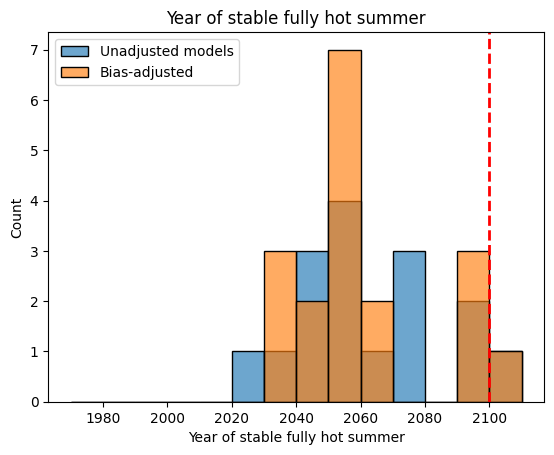

In [107]:
fig,ax = plt.subplots(1,1)
bins = np.arange(1970,2120,10)
sns.histplot(dates_df[dates_df['bias-adjusted']==False]['Year of stable fully hot summer'], ax=ax, alpha = 0.65,label='Unadjusted models',bins=bins) # plot years of reaching of consistent occurrence of 92-day-long heatwaves 
sns.histplot(dates_df[dates_df['bias-adjusted']==True]['Year of stable fully hot summer'],ax=ax,alpha=0.65,label='Bias-adjusted',bins=bins)
plt.axvline(x=2100,linewidth=2,linestyle='--',color='red')
plt.legend()
plt.title('Year of stable fully hot summer')
plt.savefig(join(datadir,'figs','year_stable_fully_hot_summer.pdf'),dpi=1200)
plt.savefig(join(datadir,'figs','year_stable_fully_hot_summer.png'))

# Compute years when X% of following years are all fully hot summer

In [108]:
df_92_days = df_global_summers[df_global_summers['Nb hot days']>=df_global_summers['JJA duration']]
print(len(np.unique(df_92_days['model'])), "models with heatwaves all summer")

34 models with heatwaves all summer


In [ ]:
percent_threshold = 80
dates_df = pd.DataFrame(index = model_list, columns=[f'Year of {percent_threshold}% stable fully hot summer','bias-adjusted'], data=None)
for model in tqdm(model_list):
    JJA_duration = df_global_summers[df_global_summers['model']==model]['JJA duration'].iloc[0]
    stable_long_heatwave_year = 2100
    first_92_heatwave_year = 2100
    if model in df_92_days['model'].to_list():
        sub_df = df_global_summers[df_global_summers['model']==model]
        year = 2099
        period_start = 1975
        while year>=period_start:
            sub_df_year = sub_df[sub_df['Year']>=year]
            if len(sub_df_year)>0 and len(sub_df_year[sub_df_year['Nb hot days']>=JJA_duration])/len(sub_df_year) < percent_threshold/100:
                break
            year = year - 1
        stable_long_heatwave_year = year + 1 # The first year with consistent occurrence of 92-day-long heatwaves is year+1 if there is no 92-day-long heatwave on year
        
    dates_df.loc[model,'bias-adjusted'] = 'Adjust' in model # 'Adjust' in model   
    dates_df.loc[model,f'Year of {percent_threshold}% stable fully hot summer'] = stable_long_heatwave_year

print(f"There are {len(dates_df[dates_df[f'Year of {percent_threshold}% stable fully hot summer']==2100])} models which never reach a level of {percent_threshold}% fully hot summer.")

100%|██████████| 34/34 [00:02<00:00, 13.62it/s]

There are 2 models which never reach a level of 80% fully hot summer.


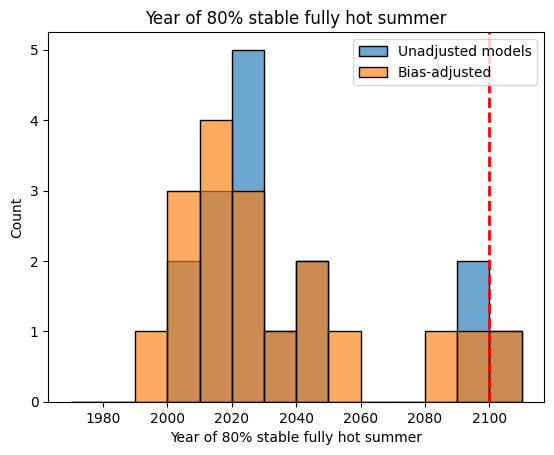

In [112]:
fig,ax = plt.subplots(1,1)
bins = np.arange(1970,2120,10)
sns.histplot(dates_df[dates_df['bias-adjusted']==False][f'Year of {percent_threshold}% stable fully hot summer'], ax=ax, alpha = 0.65,label='Unadjusted models',bins=bins) # plot years of reaching of consistent occurrence of 92-day-long heatwaves 
sns.histplot(dates_df[dates_df['bias-adjusted']==True][f'Year of {percent_threshold}% stable fully hot summer'],ax=ax,alpha=0.65,label='Bias-adjusted',bins=bins)
plt.axvline(x=2100,linewidth=2,linestyle='--',color='red')
plt.legend()
plt.title(f'Year of {percent_threshold}% stable fully hot summer')
plt.savefig(join(datadir,'figs',f'year_{percent_threshold}_stable_fully_hot_summer.pdf'),dpi=1200)
plt.savefig(join(datadir,'figs',f'year_{percent_threshold}_stable_fully_hot_summer.png'))

# Compute years with summer-long heatwaves

In [127]:
np.unique(df_htws_unadjusted['model'])

array(['ERA5',
       '_scratchu_tmandonnet_CORDEX5-Adjust_bias-adjusted-input_EUR-11_CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_RAW-NN_day_tasmax_v20260512',
       '_scratchu_tmandonnet_CORDEX5-Adjust_bias-adjusted-input_EUR-11_CLMcom_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_CLMcom-CCLM4-8-17_RAW-NN_day_tasmax_v20260512',
       '_scratchu_tmandonnet_CORDEX5-Adjust_bias-adjusted-input_EUR-11_CNRM_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CNRM-ALADIN63_RAW-NN_day_tasmax_v20260512',
       '_scratchu_tmandonnet_CORDEX5-Adjust_bias-adjusted-input_EUR-11_CNRM_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_RAW-NN_day_tasmax_v20260512',
       '_scratchu_tmandonnet_CORDEX5-Adjust_bias-adjusted-input_EUR-11_CNRM_MOHC-HadGEM2-ES_rcp85_r1i1p1_CNRM-ALADIN63_RAW-NN_day_tasmax_v20260512',
       '_scratchu_tmandonnet_CORDEX5-Adjust_bias-adjusted-input_EUR-11_DMI_NCC-NorESM1-M_rcp45_r1i1p1_DMI-HIRHAM5_RAW-NN_day_tasmax_v20260512',
       '_scratchu_tmandonnet_CORDEX5-Adjust_bias-adjusted-input_EUR-11_

In [ ]:
model_list = np.unique(df_htws_models['model'])
print(len(model_list), "models")
model_list = model_list[model_list!='ERA5']

df_92_days = df_htws_models[df_htws_models['Duration']>=90]
print(len(np.unique(df_92_days['model'])), "models with 92-day heatwaves")

34 models
33 models with 92-day heatwaves


In [ ]:
dates_df = pd.DataFrame(index = model_list, columns=['Year of stable 92-day heatwave occurrence','First year of 92-day heatwave','bias-adjusted'], data=None)
for model in tqdm(model_list):
    JJA_duration = df_global_summers[df_global_summers['model']==model]['JJA duration'].iloc[0]
    stable_long_heatwave_year = 2100
    first_92_heatwave_year = 2100
    if model in df_92_days['model'].to_list():
        sub_df = df_htws_models[df_htws_models['model']==model]
        year = 2099
        period_start = 1975
        while year>=period_start:
            sub_df_year = sub_df[sub_df['Year']==year]
            if len(sub_df_year)>0 and sub_df_year['Duration'].max() < JJA_duration:
                break
            year = year - 1
        stable_long_heatwave_year = year + 1 # The first year with consistent occurrence of 92-day-long heatwaves is year+1 if there is no 92-day-long heatwave on year
        
        year = 1975
        period_end = 2099
        while year<=period_end:
            sub_df_year = sub_df[sub_df['Year']==year]
            if len(sub_df_year)>0 and sub_df_year['Duration'].max() >= JJA_duration:
                break
            year = year + 1
        first_92_heatwave_year = year # The first year with consistent occurrence of 92-day-long heatwaves is year+1 if there is no 92-day-long heatwave on year

    dates_df.loc[model,'bias-adjusted'] = 'Adjust' in model #'Adjust' in model
    dates_df.loc[model,'Year of stable 92-day heatwave occurrence'] = stable_long_heatwave_year
    dates_df.loc[model,'First year of 92-day heatwave'] = first_92_heatwave_year

print(f'There are {len(dates_df[dates_df['Year of stable 92-day heatwave occurrence']==2100])} models which never reach a level always showing a summer-long heatwave.')
print(f'There are {len(dates_df[dates_df['First year of 92-day heatwave']==2100])} models which never show any summer-long heatwave.')

100%|██████████| 33/33 [00:04<00:00,  7.15it/s]

There are 3 models which never reach a level always showing a summer-long heatwave.
There are 0 models which never show any summer-long heatwave.


In [122]:
dates_df[(dates_df['Year of stable 92-day heatwave occurrence']==2100) | (dates_df['First year of 92-day heatwave']==2100)].iloc[:,:2]

,Year of stable 92-day heatwave occurrence,First year of 92-day heatwave
CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,2100,2062
MPI-CSC_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_MPI-CSC-REMO2009_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,2100,2050
_scratchu_tmandonnet_CORDEX5-Adjust_bias-adjusted-input_EUR-11_MPI-CSC_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_MPI-CSC-REMO2009_RAW-NN_day_tasmax_v20260512,2100,2055


In [123]:
dates_df[(dates_df['Year of stable 92-day heatwave occurrence']<=2020) | (dates_df['First year of 92-day heatwave']<=2020)].iloc[:,:2]

,Year of stable 92-day heatwave occurrence,First year of 92-day heatwave
CNRM_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,2099,1983
CNRM_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,2058,1983
CNRM_MOHC-HadGEM2-ES_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,2056,2002
DMI_NCC-NorESM1-M_rcp45_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,2065,1991
DMI_NCC-NorESM1-M_rcp85_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,2037,1991
KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,2052,1986
KNMI_ICHEC-EC-EARTH_rcp85_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,2034,1986
SMHI_ICHEC-EC-EARTH_rcp85_r1i1p1_SMHI-RCA4_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512,2034,1997
_scratchu_tmandonnet_CORDEX5-Adjust_bias-adjusted-input_EUR-11_CNRM_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CNRM-ALADIN63_RAW-NN_day_tasmax_v20260512,2099,1983
_scratchu_tmandonnet_CORDEX5-Adjust_bias-adjusted-input_EUR-11_CNRM_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_RAW-NN_day_tasmax_v20260512,2058,1983


In [125]:
len(dates_df)

33

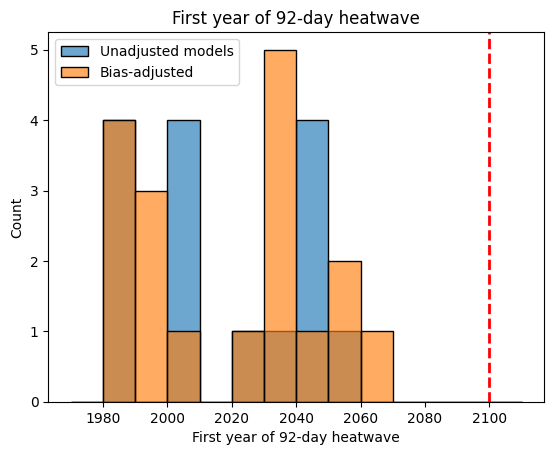

In [124]:
fig,ax = plt.subplots(1,1)
bins = np.arange(1970,2120,10)
sns.histplot(dates_df[dates_df['bias-adjusted']==False]['First year of 92-day heatwave'], ax=ax, alpha = 0.65,label='Unadjusted models',bins=bins) # plot years of reaching of consistent occurrence of 92-day-long heatwaves 
sns.histplot(dates_df[dates_df['bias-adjusted']==True]['First year of 92-day heatwave'],ax=ax,alpha=0.65,label='Bias-adjusted',bins=bins)
plt.axvline(x=2100,linewidth=2,linestyle='--',color='red')
plt.legend()
plt.title('First year of 92-day heatwave')
plt.savefig(join(datadir,'figs','first_year_92_htw.pdf'),dpi=1200)
plt.savefig(join(datadir,'figs','first_year_92_htw.png'))

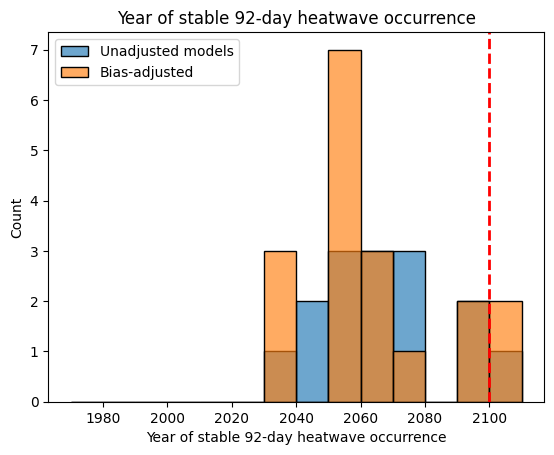

In [129]:
fig,ax = plt.subplots(1,1)
bins = np.arange(1970,2120,10)
sns.histplot(dates_df[dates_df['bias-adjusted']==False]['Year of stable 92-day heatwave occurrence'], ax=ax, alpha = 0.65,label='Unadjusted models',bins=bins) # plot years of reaching of consistent occurrence of 92-day-long heatwaves 
sns.histplot(dates_df[dates_df['bias-adjusted']==True]['Year of stable 92-day heatwave occurrence'],ax=ax,alpha=0.65,label='Bias-adjusted',bins=bins)
plt.axvline(x=2100,linewidth=2,linestyle='--',color='red')
plt.legend()
plt.title('Year of stable 92-day heatwave occurrence')
plt.savefig(join(datadir,'figs','year_stable_92_htw.pdf'),dpi=1200)
plt.savefig(join(datadir,'figs','year_stable_92_htw.png'))

# Compute trends

In [4]:
df_htws_BC_results = pd.read_csv(join(datadir,'df_htws_BC_results.csv'),header=0,index_col=0)

df_global_summers_results = pd.read_csv(join(datadir,'df_global_summers_results.csv'),header=0,index_col=0)    

df_ERA5_summers = df_global_summers_results[df_global_summers_results['model']=='ERA5']
df_ERA5 = df_htws_BC_results[df_htws_BC_results['model']=='ERA5']
df_htws_BC_results = df_htws_BC_results[df_htws_BC_results['model']!='ERA5']

model_list_BC_results = np.unique(df_htws_BC_results['model'])
model_list_BC_results

array(['CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CLMcom_MOHC-HadGEM2-ES_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CNRM_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'CNRM_MOHC-HadGEM2-ES_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'ICTP_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_ICTP-RegCM4-6_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'KNMI_ICHEC-EC-EARTH_rcp85_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
       'SMHI_ICHEC-EC-EARTH_rcp85_r1i1p1_SMHI-RCA4_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20

In [5]:
model_name_dict = {
    'CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'A45',
    'CLMcom_MOHC-HadGEM2-ES_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'A85',
    'CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'B45',
    'CLMcom_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'B85',
    'CNRM_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'D45',
    'CNRM_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'D85',
    'CNRM_MOHC-HadGEM2-ES_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'C85',
    'DMI_NCC-NorESM1-M_rcp45_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'E45',
    'DMI_NCC-NorESM1-M_rcp85_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'E85',
    'GERICS_NCC-NorESM1-M_rcp45_r1i1p1_GERICS-REMO2015_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'F45',
    'GERICS_NCC-NorESM1-M_rcp85_r1i1p1_GERICS-REMO2015_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'F85',
    'ICTP_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_ICTP-RegCM4-6_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'G85',
    'KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'H45',
    'KNMI_ICHEC-EC-EARTH_rcp85_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'H85',
    'MOHC_ICHEC-EC-EARTH_rcp85_r12i1p1_MOHC-HadREM3-GA7-05_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'I85',
    'MPI-CSC_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_MPI-CSC-REMO2009_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'J45',
    'MPI-CSC_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_MPI-CSC-REMO2009_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'J85',
    'SMHI_ICHEC-EC-EARTH_rcp85_r1i1p1_SMHI-RCA4_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'K85',
    }

In [6]:
len(df_global_summers_results[df_global_summers_results['model'].isin(model_list_BC_results)]['calendar'])

1125

In [7]:
df_mk_trends_1975_2025_fragmented = pd.read_csv(join(datadir,'df_mk_trends_1975_2025.csv'),index_col=0,header=[0,1])
df_mk_trends_2026_2099_fragmented = pd.read_csv(join(datadir,'df_mk_trends_2026_2099.csv'),index_col=0,header=[0,1])

df_mk_trends_1975_2025 = df_mk_trends_1975_2025_fragmented.copy()
df_mk_trends_2026_2099 = df_mk_trends_2026_2099_fragmented.copy()

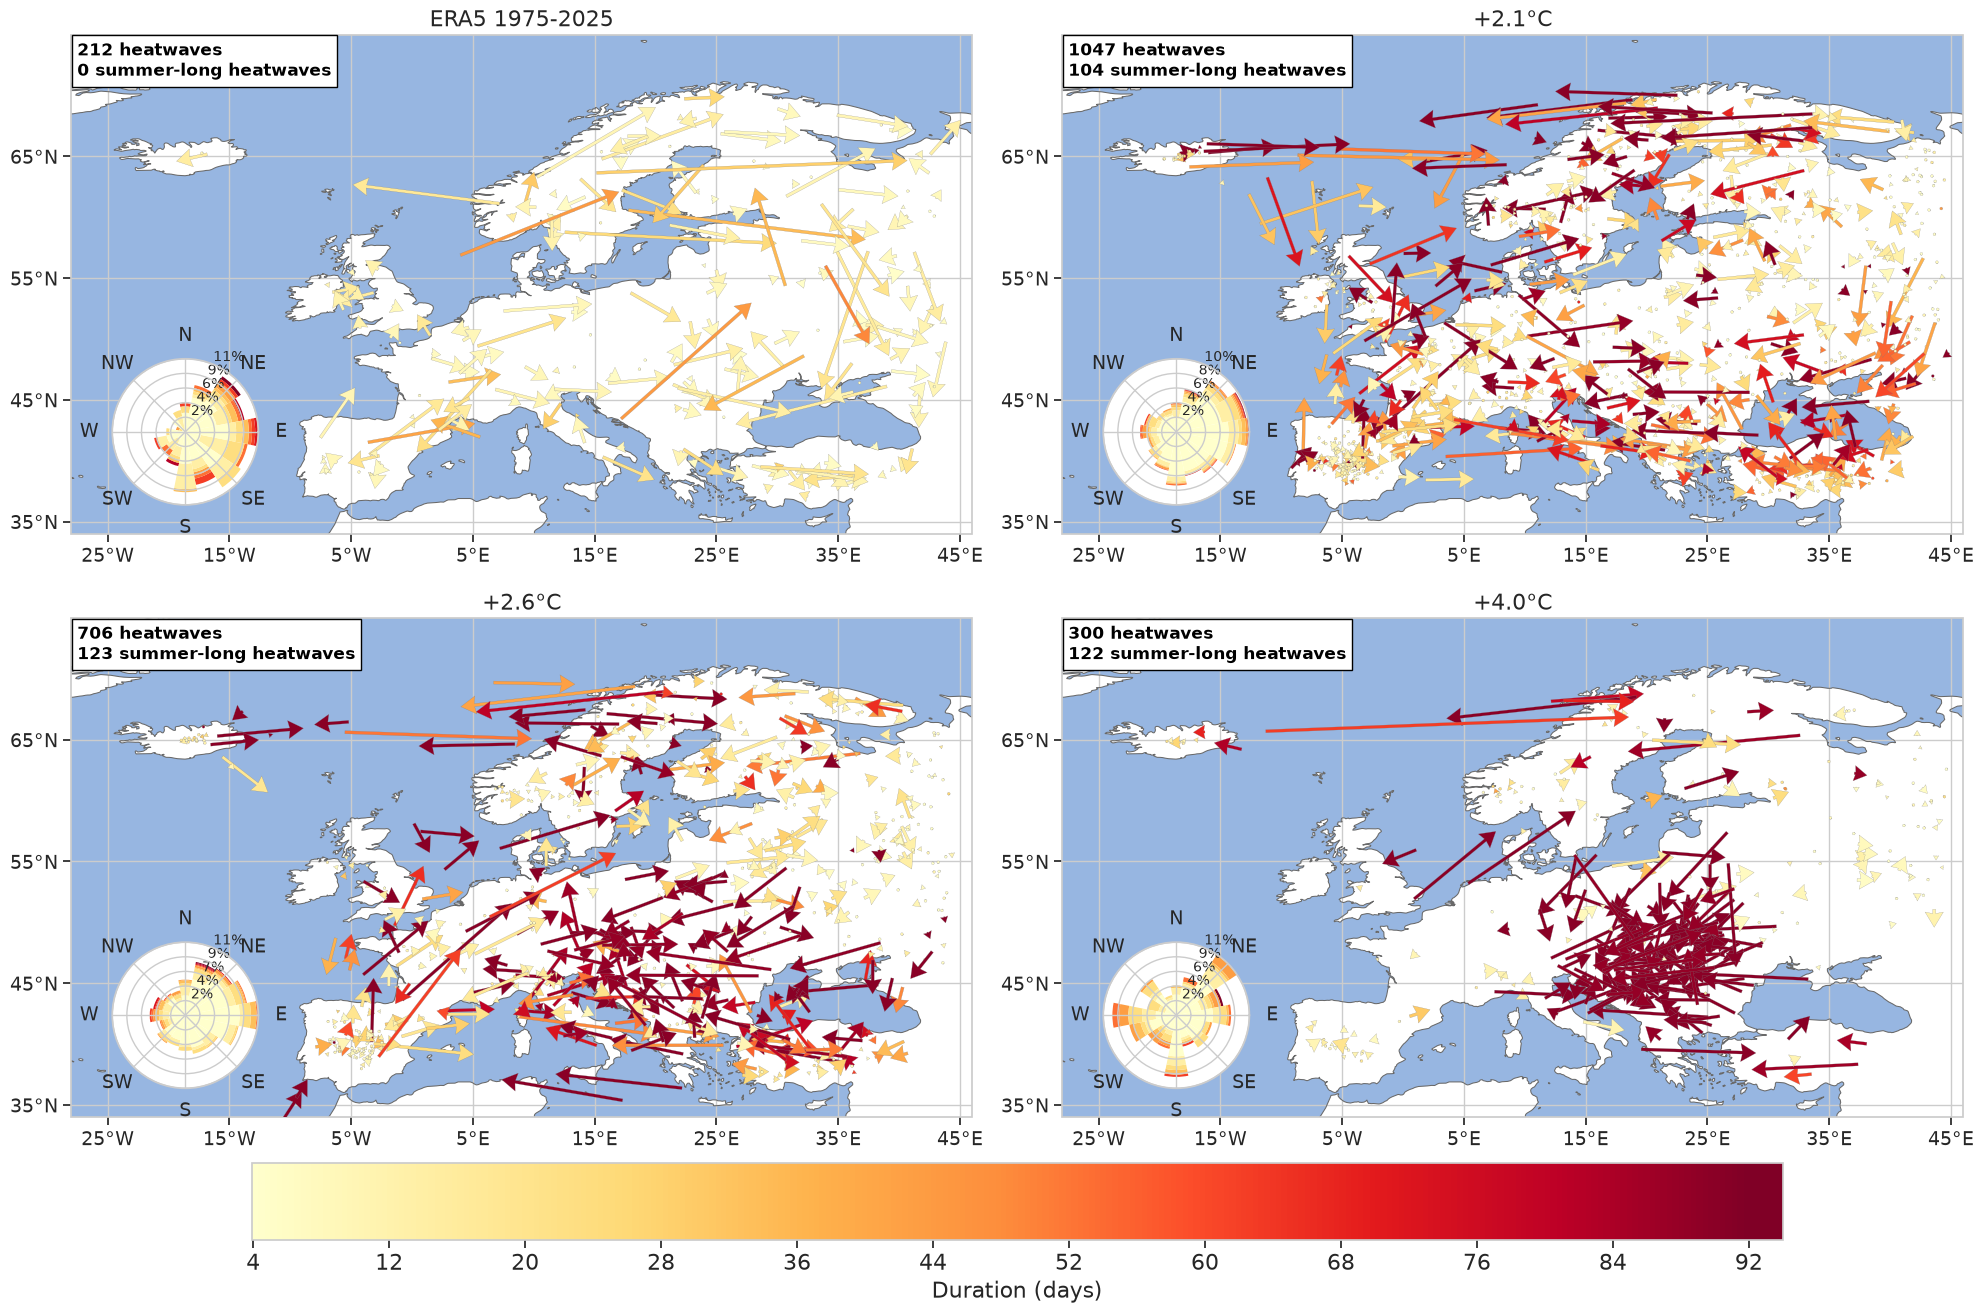

In [44]:
def movement_windrose_map(data,ax,write_directory='',var_col_arrows='Duration',var_col_arrows_unit='days',
                 cmap=cm.YlOrRd,legend = False,y_lim = False,savefig=False,
                 bins = 10, N_heatwaves=0):
    
    df_duration = 92*(data['calendar']=='noleap')+90*(data['calendar']=='360_day')
    # HW directions
    x1 = np.array([eval(p)[1] for p in data['Centroid_p1']]) # List of first longitudes 
    x2 = np.array([eval(p)[1] for p in data['Centroid_p2']]) # List of second longitudes 
    y1 = np.array([eval(p)[0] for p in data['Centroid_p1']]) # List of first latitudes 
    y2 = np.array([eval(p)[0] for p in data['Centroid_p2']]) # List of second latitudes 

    #fig = plt.figure(figsize=(10,9))   #(21,5):横版
    #ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree()) 
    levels_ = np.arange(4,94,0.1)
    ticks_ = np.arange(4,94,8)
    ax.set_extent([-28, 46, 34, 75], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, edgecolor="dimgray",linewidths = 0.75)

    hc = ax.quiver(x1,y1,x2-x1,y2-y1,data[var_col_arrows], units='xy', cmap = cmap, width = 0.25, 
                    edgecolor="grey",linewidth=0.15,
                    headwidth=6, headlength=5, headaxislength=4.5,
                    transform=ccrs.PlateCarree(),zorder=300)
    cb = plt.colorbar(hc, boundaries=levels_, ticks=ticks_,
                        orientation="horizontal", fraction=0.05, 
                        pad=0.09, extendfrac='auto',
                        extend='both', extendrect=True)
    cb.mappable.set_clim(min(levels_), max(levels_))
    cb.set_label(label=f"{var_col_arrows} ({var_col_arrows_unit})", fontsize=16)
    cb.ax.tick_params(labelsize=16) 
    cb.remove()
    # set major and minor ticks
    ax.add_feature(cfeature.OCEAN)
    ax.minorticks_on()
    ax.set_xticks(np.arange(-25, 55, 10), crs=ccrs.PlateCarree())
    ax.set_xticklabels(np.arange(-25, 55, 10), fontsize=14)
    ax.xaxis.set_minor_locator(plt.MultipleLocator(30))
    ax.xaxis.set_major_formatter(LongitudeFormatter()) 

    ax.set_yticks(np.arange(35, 75, 10), crs=ccrs.PlateCarree())
    ax.set_yticklabels(np.arange(35, 75, 10), fontsize=14)
    ax.yaxis.set_minor_locator(plt.MultipleLocator(20))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(top=False,bottom=True,left=True, right=False)

    plt.style.use('fast')
    # Windrose
    height_deg = 12
    ax2 = inset_axes(
        ax,
        width="100%",  # size in % of bbox
        height="100%",  # size in % of bbox
        # specify the center lon and lat of the plot, and size in degree
        bbox_to_anchor=(
            -24,
            37,
            height_deg,
            height_deg,
        ),
        bbox_transform=ax.transData,
        axes_class=WindroseAxes,
    )

    geodesic = pyproj.Geod(ellps='WGS84')
    _angles, _, _Delta_distance  = geodesic.inv(np.vstack(x1), 
                                                np.vstack(y1),
                                                np.vstack(x2), 
                                                np.vstack(y2))
    
    _angles[_angles<0] = 360 + _angles[_angles<0]

    ax2.bar(direction=np.reshape(_angles,-1),
           var=np.reshape(_Delta_distance,-1),
           bins=bins,
           cmap=cmap, lw=0.000001,   
           nsector=16, normed=True, opening=1, 
           edgecolor='w',alpha = 1)

    ax2.set_xticklabels(['E', 'NE', 'N', 'NW',  'W', 'SW', 'S', 'SE'], fontsize = 14)
    if legend:
        ax2.set_legend(loc='lower right', bbox_to_anchor=(1.12, -0.12), ncol=2, 
                      fontsize = 20, labelspacing=0.1, columnspacing=0.8)
    
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda s,position:'{:.0f}%'.format(s))) #设置y坐标轴以百分数显示
    
    if y_lim:
        ax2.set_yticks(np.arange(0, 25, step=3), fontsize = 10)
        ax2.set_ylim([0, 24])
    else:
        ax2.set_yticklabels("",fontsize = 10)
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda s,position:'{:.0f}%'.format(s))) #设置y坐标轴以百分数显示

    plt.tight_layout()
    if savefig:
        plt.savefig(join(write_directory,'movement_map.png'))
        plt.savefig(join(write_directory,'movement_map.pdf'),dpi=1200)
    if N_heatwaves==0:
        N_heatwaves=len(data)
    ax.text(
            x=-27.5,
            y=74.5,
            s=f'{N_heatwaves} heatwaves\n{len(data[data['Duration']==df_duration])} summer-long heatwaves',
            ha="left",
            va="top",
            fontsize=12,#self._config["reference_event_label_fontsize"],
            fontweight="bold",
            color="black",
            #rotation=45,#self._config["reference_event_label_rotation"],
            zorder=500,
            bbox=dict(
                facecolor='white',
                edgecolor='black',
                alpha=1,
                linewidth=1,
                #boxstyle="round",
            ),
            #rotation_mode="anchor",
        )

    return ax,hc
# movement_windrose_map(write_directory="/home/user/These/cordex_htws_cc3d/Data/figs",data=df)
fig,axes = plt.subplots(2,2,figsize=(20,16),subplot_kw={'projection':ccrs.PlateCarree()})
axes[0,0] = movement_windrose_map(write_directory="/home/user/These/cordex_htws_cc3d/Data/figs",data=df_ERA5,ax=axes[0,0],N_heatwaves=212)[0]
axes[0,0].set_title('ERA5 1975-2025',fontsize=16)
axes[0,1] = movement_windrose_map(write_directory="/home/user/These/cordex_htws_cc3d/Data/figs",data=df_htws_BC_results[df_htws_BC_results['Period RWL 1']],ax=axes[0,1],N_heatwaves=1047)[0]
axes[0,1].set_title('+2.1°C',fontsize=16)
axes[1,0] = movement_windrose_map(write_directory="/home/user/These/cordex_htws_cc3d/Data/figs",data=df_htws_BC_results[df_htws_BC_results['Period RWL 2']],ax=axes[1,0],N_heatwaves=706)[0]
axes[1,0].set_title('+2.6°C',fontsize=16)
axes[1,1],hc = movement_windrose_map(write_directory="/home/user/These/cordex_htws_cc3d/Data/figs",data=df_htws_BC_results[df_htws_BC_results['Period RWL 3']],ax=axes[1,1],N_heatwaves=300)
axes[1,1].set_title('+4.0°C',fontsize=16)
levels_ = np.arange(4,94,0.1)
ticks_ = np.arange(4,94,8)
norm = clrs.Normalize(vmin=4, vmax=92)
sm = plt.cm.ScalarMappable(cmap="YlOrRd",norm=norm)
sm.set_array([])
cb = fig.figure.colorbar(sm,ax=axes,boundaries=levels_, ticks=ticks_,
                        orientation="horizontal", fraction=0.05, 
                        pad=0.03, extendfrac='auto',
                        extend='both', extendrect=True)
cb.set_label(label=f"Duration (days)", fontsize=16)
cb.ax.tick_params(labelsize=16)
plt.savefig(join(datadir,'figs','movement_4_panels.png'),bbox_inches='tight')
plt.savefig(join(datadir,'figs','movement_4_panels.pdf'),dpi=1200,bbox_inches='tight')
plt.show()

In [ ]:
marker_dict = {True:'o', False:'v'}
color_dict = {True:'red',False:'lightsalmon'}

index_list = ['Frequency','Nb hot days','Accumulated area summer','Mean duration summer','Max duration summer',
    'Mean spatial extent summer', 'Max spatial extent summer', 'Mean accumulated area summer', 'Max accumulated area summer',
    'Mean speed summer','Max speed summer','Mean distance summer','Max distance summer',
    'Intensity','Spatial extent', 'Mean spatial extent', 'Relative spatial extent (%)','Relative mean spatial extent (%)','Accumulated area',
    'Duration','Max','HWMId_sum',
    'Exposed_population_ssp1_all_period','HWMId_pop_ssp1_all_period',
    'Exposed_population_ssp2_all_period','HWMId_pop_ssp2_all_period','Exposed_population_ssp3_all_period','HWMId_pop_ssp3_all_period',
    'Exposed_population_ssp4_all_period','HWMId_pop_ssp4_all_period','Exposed_population_ssp5_all_period','HWMId_pop_ssp5_all_period',
    'Total_exposed_population_ssp1_all_period','Total_exposed_population_ssp2_all_period','Total_exposed_population_ssp3_all_period',
    'Total_exposed_population_ssp4_all_period','Total_exposed_population_ssp5_all_period','Speed','Distance','Relative accumulated area (%)','Relative accumulated area summer (%)']

x_start_hist = 5
x_end_hist = x_start_hist + len(np.unique(df_htws_BC_results['model']))
x_start_rcp45 = x_end_hist + 4
x_end_rcp45 = x_start_rcp45 + len(np.unique(df_htws_BC_results[df_htws_BC_results['simulation']=='rcp45']['model']))
x_start_rcp85 = x_end_rcp45 + 4
x_end_rcp85 = x_start_rcp85 + len(np.unique(df_htws_BC_results[df_htws_BC_results['simulation']=='rcp85']['model']))

xticks = [1,
x_start_hist+(x_end_hist-x_start_hist)/2,
x_start_rcp45+(x_end_rcp45-x_start_rcp45)/2,
x_start_rcp85+(x_end_rcp85-x_start_rcp85)/2]
xlabels = ['ERA5', 'Historical', 'RCP4.5 runs', 'RCP8.5 runs']

unit_dict = {'Frequency':'heatwaves/decade','Nb hot days':'days/decade','Accumulated area summer':'km²/decade',
'Mean duration summer':'days/decade','Max duration summer':'days/decade',
'Mean spatial extent summer':'km²/decade', 'Max spatial extent summer':'km²/decade', 'Mean accumulated area summer':'km²/decade', 'Max accumulated area summer':'km²/decade',
'Mean speed summer':'km/day/decade','Max speed summer':'km/day/decade','Mean distance summer':'km/decade','Max distance summer':'km/decade',
'Intensity':'°C/decade','Spatial extent':'km²/decade','Mean spatial extent':'km²/decade',
'Relative spatial extent (%)':'%/decade','Relative mean spatial extent (%)':'%/decade','Accumulated area':'km²/decade',
'Duration':'days/decade','Max':'°C/decade','HWMId_sum':'IQR-km²/decade','Exposed_population_ssp1_all_period':'people/decade',
'HWMId_pop_ssp1_all_period':'IQR-persons/decade',
'Exposed_population_ssp2_all_period':'people/decade','HWMId_pop_ssp2_all_period':'IQR-persons/decade','Exposed_population_ssp3_all_period':'people/decade',
'HWMId_pop_ssp3_all_period':'IQR-persons/decade','Exposed_population_ssp4_all_period':'people/decade',
'HWMId_pop_ssp4_all_period':'IQR-persons/decade','Exposed_population_ssp5_all_period':'people/decade','HWMId_pop_ssp5_all_period':'IQR-persons/decade',
'Total_exposed_population_ssp1_all_period':'people/decade','Total_exposed_population_ssp2_all_period':'people/decade',
'Total_exposed_population_ssp3_all_period':'people/decade','Total_exposed_population_ssp4_all_period':'people/decade','Total_exposed_population_ssp5_all_period':'people/decade',
'Speed':'km/day/decade','Distance':'km/decade','Relative accumulated area summer (%)':'%/decade','Relative accumulated area (%)':'%/decade'}

not_log_list = ['Frequency','Nb hot days','Mean duration summer','Mean speed summer','Max speed summer','Mean distance summer',
    'Max distance summer','Max duration summer','Duration summer','Intensity','Duration','Max','Distance','Speed',
    'Relative accumulated area (%)', 'Relative accumulated area summer (%)','Relative spatial extent (%)','Relative mean spatial extent (%)']

def per_decade(x):
    return x*10

for i,index in tqdm(enumerate(index_list)):
    fig,ax = plt.subplots(1,1,figsize=(8,6))
    x_p_historical = 5
    x_p_rcp45 = len(np.unique(df_htws_BC_results['model'])) + x_p_historical + 4
    x_p_rcp85 = len(np.unique(df_htws_BC_results[df_htws_BC_results['simulation']=='rcp45']['model'])) + x_p_rcp45 + 4

    marker_ = marker_dict[bool(df_mk_trends_1975_2025.loc['ERA5',(index,'ss')]==95)]
    ax.scatter(1,per_decade(df_mk_trends_1975_2025.loc['ERA5',(index,'slope')]),c='black',marker=marker_,s=25,zorder=100)
    ax.vlines(x=1, ymin=per_decade(df_mk_trends_1975_2025.loc['ERA5',(index,'lcl')]), ymax=per_decade(df_mk_trends_1975_2025.loc['ERA5',(index,'ucl')]),zorder=50,colors='black',alpha=0.5)
    ax.grid(visible=True)
    ax.axvline(x=3,linewidth=2,linestyle='--',zorder=20)
    ax.axvline(x=x_end_hist+2,linewidth=2,linestyle='--',zorder=20)
    ax.axvline(x=x_end_rcp45+2,linewidth=2,linestyle='--',zorder=20)
    ax.axhline(y=0,linewidth=0.75,color='k',linestyle='-',zorder=10)
    ax.set_xticks(xticks, labels=xlabels,rotation=45,ha='right')
    ax.set_ylabel(unit_dict[index])

    if index not in not_log_list:
        try:
            ax.set_yscale("log")
        except:
            ax.set_yscale("log", nonpositive='clip')

    for model in model_list_BC_results:
        col = color_dict[bool(df_mk_trends_1975_2025.loc[model,(index,'ss')]==95)]
        marker_ = marker_dict[bool(df_mk_trends_1975_2025.loc[model,(index,'ss')]==95)]
        ax.scatter(x_p_historical,per_decade(df_mk_trends_1975_2025.loc[model,(index,'slope')]),c=col,marker=marker_,s=25,zorder=100)
        ax.vlines(x=x_p_historical, ymin=per_decade(df_mk_trends_1975_2025.loc[model,(index,'lcl')]), ymax=per_decade(df_mk_trends_1975_2025.loc[model,(index,'ucl')]),zorder=50,colors='black',alpha=0.5)
        
        col = color_dict[bool(df_mk_trends_2026_2099.loc[model,(index,'ss')]==95)]
        marker_ = marker_dict[bool(df_mk_trends_2026_2099.loc[model,(index,'ss')]==95)]
        if 'rcp45' in model:
            ax.scatter(x_p_rcp45,per_decade(df_mk_trends_2026_2099.loc[model,(index,'slope')]),c=col,marker=marker_,s=25,zorder=100)
            ax.vlines(x=x_p_rcp45, ymin=per_decade(df_mk_trends_2026_2099.loc[model,(index,'lcl')]), ymax=per_decade(df_mk_trends_2026_2099.loc[model,(index,'ucl')]),zorder=50,colors='black',alpha=0.5)
        elif 'rcp85' in model:
            ax.scatter(x_p_rcp85,per_decade(df_mk_trends_2026_2099.loc[model,(index,'slope')]),c=col,marker=marker_,s=25,zorder=100)
            ax.vlines(x=x_p_rcp85, ymin=per_decade(df_mk_trends_2026_2099.loc[model,(index,'lcl')]), ymax=per_decade(df_mk_trends_2026_2099.loc[model,(index,'ucl')]),zorder=50,colors='black',alpha=0.5)
        x_p_historical += 1
        if 'rcp45' in model:
            x_p_rcp45 += 1
        elif 'rcp85' in model:
            x_p_rcp85 += 1

    if index == 'Accumulated area summer' :
        ax.set_ylim([1e5,1e9])
    
    fig.suptitle(index)

    point_1 = Line2D([0], [0], label='Significant trend', marker='o', markersize=5, 
            markeredgecolor='red', markerfacecolor='red', linestyle='')
    point_2 = Line2D([0], [0], label='Not sig. trend', marker='v', markersize=5, 
            markeredgecolor='lightsalmon', markerfacecolor='lightsalmon', linestyle='')

    ax.legend(handles=[point_1,point_2],loc='best').set_zorder(300)
    plt.tight_layout()
    fig.savefig(join(datadir,'figs',f'trends_{index.replace(" ","_")}.pdf'),dpi=1200)
    fig.savefig(join(datadir,'figs',f'trends_{index.replace(" ","_")}.png'))
    plt.close()

0it [00:00, ?it/s]

40it [00:19,  2.10it/s]


In [ ]:
marker_dict = {True:'o', False:'v'}
color_dict = {True:'red',False:'lightsalmon'}

index_list = ['Frequency','Nb hot days','Accumulated area summer','Mean duration summer','Max duration summer',
    'Mean spatial extent summer', 'Max spatial extent summer', 'Mean accumulated area summer', 'Max accumulated area summer',
    'Mean speed summer','Max speed summer','Mean distance summer','Max distance summer',
    'Intensity','Spatial extent', 'Mean spatial extent', 'Relative spatial extent (%)','Relative mean spatial extent (%)','Accumulated area',
    'Duration','Max','HWMId_sum',
    'Exposed_population_ssp1_all_period','HWMId_pop_ssp1_all_period',
    'Exposed_population_ssp2_all_period','HWMId_pop_ssp2_all_period','Exposed_population_ssp3_all_period','HWMId_pop_ssp3_all_period',
    'Exposed_population_ssp4_all_period','HWMId_pop_ssp4_all_period','Exposed_population_ssp5_all_period','HWMId_pop_ssp5_all_period',
    'Total_exposed_population_ssp1_all_period','Total_exposed_population_ssp2_all_period','Total_exposed_population_ssp3_all_period',
    'Total_exposed_population_ssp4_all_period','Total_exposed_population_ssp5_all_period','Speed','Distance','Relative accumulated area (%)','Relative accumulated area summer (%)']

unit_dict = {'Frequency':'htw/dec','Nb hot days':'d/dec','Accumulated area summer':'km²/dec',
'Mean duration summer':'d/dec','Max duration summer':'d/dec',
'Mean spatial extent summer':'km²/dec', 'Max spatial extent summer':'km²/dec', 'Mean accumulated area summer':'km²/dec', 'Max accumulated area summer':'km²/dec',
'Mean speed summer':'km/d/dec','Max speed summer':'km/d/dec','Mean distance summer':'km/dec','Max distance summer':'km/dec',
'Intensity':'°C/dec','Spatial extent':'km²/dec','Mean spatial extent':'km²/dec','Relative spatial extent (%)':'%/dec','Relative mean spatial extent (%)':'%/dec','Accumulated area':'km²/dec',
'Duration':'d/dec','Max':'°C/dec','HWMId_sum':'IQR-km²/dec','Exposed_population_ssp1_all_period':'ppl/dec',
'HWMId_pop_ssp1_all_period':'IQR-persons/dec',
'Exposed_population_ssp2_all_period':'ppl/dec','HWMId_pop_ssp2_all_period':'IQR-persons/dec','Exposed_population_ssp3_all_period':'ppl/dec',
'HWMId_pop_ssp3_all_period':'IQR-persons/dec','Exposed_population_ssp4_all_period':'ppl/dec',
'HWMId_pop_ssp4_all_period':'IQR-persons/dec','Exposed_population_ssp5_all_period':'ppl/dec','HWMId_pop_ssp5_all_period':'IQR-persons/dec',
'Total_exposed_population_ssp1_all_period':'ppl/dec','Total_exposed_population_ssp2_all_period':'ppl/dec',
'Total_exposed_population_ssp3_all_period':'ppl/dec','Total_exposed_population_ssp4_all_period':'ppl/dec','Total_exposed_population_ssp5_all_period':'ppl/dec',
'Speed':'km/d/dec','Distance':'km/dec','Relative accumulated area summer (%)':'%/dec','Relative accumulated area (%)':'%/dec'}

summer_index_list = ['Frequency','Nb hot days','Accumulated area summer','Mean duration summer','Max duration summer',
    'Mean spatial extent summer', 'Max spatial extent summer', 'Mean accumulated area summer', 'Max accumulated area summer',
    'Mean speed summer','Max speed summer','Mean distance summer','Max distance summer','Relative accumulated area summer (%)']

not_log_list = ['Frequency','Nb hot days','Mean duration summer','Mean speed summer','Max speed summer','Mean distance summer',
    'Max distance summer','Max duration summer','Duration summer','Intensity','Duration','Max','Distance','Speed',
    'Relative accumulated area (%)', 'Relative accumulated area summer (%)','Relative spatial extent (%)','Relative mean spatial extent (%)']

def per_decade(x):
    return x*10

for i,index in tqdm(enumerate(index_list)):
    #fig,axes = plt.subplots(3,4)
    fig,axes = plt.subplots(ncols=5,nrows=3,width_ratios=[4,4,0.5,4,4],figsize=(18,12),sharey=True,sharex=True,gridspec_kw={'wspace':0.2})
    k=0
    for model in model_list_BC_results:
        if k==3:
            k+=1
        ax = axes[k//4][k%4]

        if index not in not_log_list:
            try:
                ax.set_yscale("log")
            except:
                ax.set_yscale("log", nonpositive='clip')

        if index in summer_index_list:
            subplot_df = df_global_summers_results[df_global_summers_results['model']==model]
        else:
            subplot_df = df_htws_BC_results[df_htws_BC_results['model']==model]
        sns.scatterplot(data=subplot_df[subplot_df['Year']<=2025],x='Year',y=index,ax=ax,color=color_dict[bool(df_mk_trends_1975_2025.loc[model,(index,'ss')]==95)],marker=marker_dict[bool(df_mk_trends_1975_2025.loc[model,(index,'ss')]==95)])
        sns.scatterplot(data=subplot_df[subplot_df['Year']>=2026],x='Year',y=index,ax=ax,color=color_dict[bool(df_mk_trends_2026_2099.loc[model,(index,'ss')]==95)],marker=marker_dict[bool(df_mk_trends_2026_2099.loc[model,(index,'ss')]==95)])
        ax.axvline(x=2025,linewidth=1,linestyle='--')
        ax.set_title(model_name_dict[model])
        ax.annotate(text ='slope:\n%.1E\n%s' % (per_decade(df_mk_trends_1975_2025.loc[model,(index,'slope')]),unit_dict[index]),xy=(0.05,0.8),xycoords='axes fraction')
        ax.annotate(text ='slope:\n%.1E\n%s' % (per_decade(df_mk_trends_2026_2099.loc[model,(index,'slope')]),unit_dict[index]),xy=(0.6,0.05),xycoords='axes fraction')
        k += 1
    if index == 'Accumulated area summer':
        ax.set_ylim([1e5,1e9])
    fig.suptitle(index)

    ax = axes[0][0]
    ax.axis("off")
    point_1 = Line2D([0], [0], label='Significant trend', marker='o', markersize=5, 
        markeredgecolor='red', markerfacecolor='red', linestyle='')
    point_2 = Line2D([0], [0], label='Not sig. trend', marker='v', markersize=5, 
            markeredgecolor='lightsalmon', markerfacecolor='lightsalmon', linestyle='')
    point_3 = Line2D([0], [0], label='ERA5', marker='o', markersize=5, 
        markeredgecolor='k', markerfacecolor='k', linestyle='')
    ax.legend(handles=[point_1,point_2,point_3],loc='center').set_zorder(300)

    ax = axes[1][0]
    if index in summer_index_list:
        subplot_df = df_ERA5_summers
    else:
        subplot_df = df_ERA5
    sns.scatterplot(data=subplot_df,x='Year',y=index,ax=ax,color='black')
    ax.axvline(x=2025,linewidth=1,linestyle='--')
    ax.set_title('ERA5')
    ax.annotate(text ='slope:\n%.1E\n%s' % (per_decade(df_mk_trends_1975_2025.loc[model,(index,'slope')]),unit_dict[index]),xy=(0.05,0.8),xycoords='axes fraction')

    fig.suptitle(index)
    fig.savefig(join(datadir,'figs',f'models_scatter_{index.replace(" ","_")}.pdf'),dpi=1200)
    fig.savefig(join(datadir,'figs',f'models_scatter_{index.replace(" ","_")}.png'))
    plt.close()

40it [01:12,  1.81s/it]


In [8]:
model_name_dict = {
    'CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'A45',
    'CLMcom_MOHC-HadGEM2-ES_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'A85',
    'CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'B45',
    'CLMcom_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'B85',
    'CNRM_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'D45',
    'CNRM_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'D85',
    'CNRM_MOHC-HadGEM2-ES_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'C85',
    'DMI_NCC-NorESM1-M_rcp45_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'E45',
    'DMI_NCC-NorESM1-M_rcp85_r1i1p1_DMI-HIRHAM5_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'E85',
    'GERICS_NCC-NorESM1-M_rcp45_r1i1p1_GERICS-REMO2015_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'F45',
    'GERICS_NCC-NorESM1-M_rcp85_r1i1p1_GERICS-REMO2015_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'F85',
    'ICTP_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_ICTP-RegCM4-6_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'G85',
    'KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'H45',
    'KNMI_ICHEC-EC-EARTH_rcp85_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'H85',
    'MOHC_ICHEC-EC-EARTH_rcp85_r12i1p1_MOHC-HadREM3-GA7-05_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'I85',
    'MPI-CSC_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_MPI-CSC-REMO2009_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'J45',
    'MPI-CSC_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_MPI-CSC-REMO2009_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'J85',
    'SMHI_ICHEC-EC-EARTH_rcp85_r1i1p1_SMHI-RCA4_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512':'K85',
    }

In [21]:
df_global_summers_results[(df_global_summers_results['Year']<=2025)&(df_global_summers_results['model']=='CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512')]['Accumulated area summer']

875    6.756562e+06
876    2.359646e+05
877    2.568213e+06
878    2.662887e+06
879    0.000000e+00
880    0.000000e+00
881    0.000000e+00
882    2.694990e+07
883    2.826836e+06
884    1.085672e+06
885    5.237856e+06
886    5.728028e+06
887    0.000000e+00
888    2.719687e+06
889    3.149136e+06
890    5.740784e+06
891    5.303561e+06
892    6.350584e+06
893    4.341930e+06
894    1.007762e+06
895    5.180520e+06
896    5.662876e+06
897    4.942025e+06
898    2.037707e+07
899    1.061747e+07
900    5.387367e+06
901    1.641696e+07
902    1.446251e+07
903    3.855465e+05
904    9.773129e+05
905    1.615165e+07
906    7.939565e+06
907    6.666885e+06
908    3.000202e+06
909    3.748739e+06
910    1.828688e+07
911    8.344450e+06
912    1.187672e+07
913    1.740264e+07
914    1.385832e+07
915    1.861737e+07
916    1.631395e+07
917    1.571075e+07
918    6.082122e+06
919    6.420252e+06
920    2.943908e+07
921    2.534078e+07
922    5.586057e+06
923    1.089210e+06
924    1.943552e+07


In [22]:
marker_dict = {True:'o', False:'v'}
color_dict = {True:'red',False:'lightsalmon'}

rcp45_list = [
'CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
'CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
'KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
]

rcp85_list = [
'CLMcom_MOHC-HadGEM2-ES_rcp85_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
'CNRM_MOHC-HadGEM2-ES_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
'CNRM_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
'ICTP_MPI-M-MPI-ESM-LR_rcp85_r1i1p1_ICTP-RegCM4-6_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
'KNMI_ICHEC-EC-EARTH_rcp85_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
'SMHI_ICHEC-EC-EARTH_rcp85_r1i1p1_SMHI-RCA4_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512',
]

index_list = ['Frequency','Nb hot days','Accumulated area summer','Mean duration summer','Max duration summer',
    'Mean spatial extent summer', 'Max spatial extent summer', 'Mean accumulated area summer', 'Max accumulated area summer',
    'Mean speed summer','Max speed summer','Mean distance summer','Max distance summer',
    'Intensity','Spatial extent', 'Mean spatial extent', 'Relative spatial extent (%)','Relative mean spatial extent (%)','Accumulated area',
    'Duration','Max','HWMId_sum',
    'Exposed_population_ssp1_all_period','HWMId_pop_ssp1_all_period',
    'Exposed_population_ssp2_all_period','HWMId_pop_ssp2_all_period','Exposed_population_ssp3_all_period','HWMId_pop_ssp3_all_period',
    'Exposed_population_ssp4_all_period','HWMId_pop_ssp4_all_period','Exposed_population_ssp5_all_period','HWMId_pop_ssp5_all_period',
    'Total_exposed_population_ssp1_all_period','Total_exposed_population_ssp2_all_period','Total_exposed_population_ssp3_all_period',
    'Total_exposed_population_ssp4_all_period','Total_exposed_population_ssp5_all_period','Speed','Distance','Relative accumulated area (%)','Relative accumulated area summer (%)']

unit_dict = {'Frequency':'htw/dec','Nb hot days':'d/dec','Accumulated area summer':'km²/dec',
'Mean duration summer':'d/dec','Max duration summer':'d/dec',
'Mean spatial extent summer':'km²/dec', 'Max spatial extent summer':'km²/dec', 'Mean accumulated area summer':'km²/dec', 'Max accumulated area summer':'km²/dec',
'Mean speed summer':'km/d/dec','Max speed summer':'km/d/dec','Mean distance summer':'km/dec','Max distance summer':'km/dec',
'Intensity':'°C/dec','Spatial extent':'km²/dec','Mean spatial extent':'km²/dec','Relative spatial extent (%)':'%/dec','Relative mean spatial extent (%)':'%/dec','Accumulated area':'km²/dec',
'Duration':'d/dec','Max':'°C/dec','HWMId_sum':'IQR-km²/dec','Exposed_population_ssp1_all_period':'ppl/dec',
'HWMId_pop_ssp1_all_period':'IQR-persons/dec',
'Exposed_population_ssp2_all_period':'ppl/dec','HWMId_pop_ssp2_all_period':'IQR-persons/dec','Exposed_population_ssp3_all_period':'ppl/dec',
'HWMId_pop_ssp3_all_period':'IQR-persons/dec','Exposed_population_ssp4_all_period':'ppl/dec',
'HWMId_pop_ssp4_all_period':'IQR-persons/dec','Exposed_population_ssp5_all_period':'ppl/dec','HWMId_pop_ssp5_all_period':'IQR-persons/dec',
'Total_exposed_population_ssp1_all_period':'ppl/dec','Total_exposed_population_ssp2_all_period':'ppl/dec',
'Total_exposed_population_ssp3_all_period':'ppl/dec','Total_exposed_population_ssp4_all_period':'ppl/dec','Total_exposed_population_ssp5_all_period':'ppl/dec',
'Speed':'km/d/dec','Distance':'km/dec','Relative accumulated area summer (%)':'%/dec','Relative accumulated area (%)':'%/dec'}

summer_index_list = ['Frequency','Nb hot days','Accumulated area summer','Mean duration summer','Max duration summer',
    'Mean spatial extent summer', 'Max spatial extent summer', 'Mean accumulated area summer', 'Max accumulated area summer',
    'Mean speed summer','Max speed summer','Mean distance summer','Max distance summer','Relative accumulated area summer (%)']

not_log_list = ['Frequency','Nb hot days','Mean duration summer','Mean speed summer','Max speed summer','Mean distance summer',
    'Max distance summer','Max duration summer','Duration summer','Intensity','Duration','Max','Distance','Speed',
    'Relative accumulated area (%)', 'Relative accumulated area summer (%)','Relative spatial extent (%)','Relative mean spatial extent (%)']

labels = [' ', 'RCP 4.5', 'RCP 8.5']

def per_decade(x):
    return x*10

slope_location_right = {'Duration':0.5, 'Spatial extent':0.05, 'Mean spatial extent':0.05,'Nb hot days':0.05,'Relative mean spatial extent (%)':0.05,
'Frequency':0.05,'Accumulated area summer':0.05,
'Mean duration summer':0.05,'Max duration summer':0.05,
'Mean spatial extent summer':0.05, 'Max spatial extent summer':0.05, 'Mean accumulated area summer':0.05, 'Max accumulated area summer':0.05,
'Mean speed summer':0.05,'Max speed summer':0.05,'Mean distance summer':0.05,'Max distance summer':0.05,
'Intensity':0.05,'Relative spatial extent (%)':0.05,'Accumulated area':0.05,
'Max':0.05,'HWMId_sum':0.05,'Exposed_population_ssp1_all_period':0.05,
'HWMId_pop_ssp1_all_period':0.05,
'Exposed_population_ssp2_all_period':0.05,'HWMId_pop_ssp2_all_period':0.05,'Exposed_population_ssp3_all_period':0.05,
'HWMId_pop_ssp3_all_period':0.05,'Exposed_population_ssp4_all_period':0.05,
'HWMId_pop_ssp4_all_period':0.05,'Exposed_population_ssp5_all_period':0.05,'HWMId_pop_ssp5_all_period':0.05,
'Total_exposed_population_ssp1_all_period':0.05,'Total_exposed_population_ssp2_all_period':0.05,
'Total_exposed_population_ssp3_all_period':0.05,'Total_exposed_population_ssp4_all_period':0.05,'Total_exposed_population_ssp5_all_period':0.05,
'Speed':0.05,'Distance':0.05,'Relative accumulated area summer (%)':0.05,'Relative accumulated area (%)':0.05}

for index in tqdm(slope_location_right.keys()):#['Duration', 'Spatial extent', 'Mean spatial extent','Nb hot days','Relative mean spatial extent (%)']:
    fig = plt.figure(constrained_layout=True,figsize=(18,14))
    subfigs = fig.subfigures(1, 3,width_ratios=[1,1,1.8])

    if index in summer_index_list:
        subplot_df = df_global_summers_results[index]
        y_max = 1.05*np.max([df_ERA5_summers[index].max(),subplot_df.max()])
        y_min = 0.95*np.min([df_ERA5_summers[index].min(),subplot_df.min()])
    else:
        subplot_df = df_htws_BC_results[index]
        y_max = 1.05*np.max([df_ERA5[index].max(),subplot_df.max()])
        y_min = 0.95*np.min([df_ERA5[index].min(),subplot_df.min()])

    if y_min==0:
        y_min = -1

    subfig = subfigs.flat[0]
    subfig.suptitle(labels[0])
    axs = subfig.subplots(3, 1,height_ratios=[1,0.92,1])
    ax = axs.flat[0]
    ax.axis("off")
    point_1 = Line2D([0], [0], label='Significant trend', marker='o', markersize=5, 
        markeredgecolor='red', markerfacecolor='red', linestyle='')
    point_2 = Line2D([0], [0], label='Not sig. trend', marker='v', markersize=5, 
        markeredgecolor='lightsalmon', markerfacecolor='lightsalmon', linestyle='')
    point_3 = Line2D([0], [0], label='ERA5', marker='o', markersize=5, 
        markeredgecolor='k', markerfacecolor='k', linestyle='')
    ax.legend(handles=[point_1,point_2,point_3],loc='center').set_zorder(300)
    axs.flat[2].axis("off")
    ax = axs.flat[1]
    if index in summer_index_list:
        subplot_df = df_ERA5_summers
    else:
        subplot_df = df_ERA5
    sns.scatterplot(data=subplot_df,x='Year',y=index,ax=ax,color='black')
    ax.set_ylim([y_min,y_max])
    ax.set_xlim([1970,2100])
    ax.axvline(x=2025,linewidth=1,linestyle='--')
    ax.set_title('ERA5')
    ax.annotate(text ='slope:\n%.1E\n%s' % (per_decade(df_mk_trends_1975_2025.loc['ERA5',(index,'slope')]),unit_dict[index]),xy=(0.05,0.8),xycoords='axes fraction')
    ax.grid('on')
    if index not in not_log_list:
        try:
            ax.set_yscale("log")
        except:
            ax.set_yscale("log", nonpositive='clip')

    subfig = subfigs.flat[1]
    subfig.suptitle(labels[1])
    axs = subfig.subplots(3, 1,sharex=True,sharey=True)
    for innerind, ax in enumerate(axs.flat):
        ax.grid('on')
        ax.set_ylim([y_min,y_max])
        model = rcp45_list[innerind]
        if index in summer_index_list:
            subplot_df = df_global_summers_results[df_global_summers_results['model']==model]
        else:
            subplot_df = df_htws_BC_results[df_htws_BC_results['model']==model]
        sns.scatterplot(data=subplot_df[subplot_df['Year']<=2025],x='Year',y=index,ax=ax,color=color_dict[bool(df_mk_trends_1975_2025.loc[model,(index,'ss')]==95)],marker=marker_dict[bool(df_mk_trends_1975_2025.loc[model,(index,'ss')]==95)])
        sns.scatterplot(data=subplot_df[subplot_df['Year']>=2026],x='Year',y=index,ax=ax,color=color_dict[bool(df_mk_trends_2026_2099.loc[model,(index,'ss')]==95)],marker=marker_dict[bool(df_mk_trends_2026_2099.loc[model,(index,'ss')]==95)])
        ax.axvline(x=2025,linewidth=1,linestyle='--')
        ax.set_title(model_name_dict[model])
        ax.annotate(text ='slope:\n%.1E\n%s' % (per_decade(df_mk_trends_1975_2025.loc[model,(index,'slope')]),unit_dict[index]),xy=(0.05,0.8),xycoords='axes fraction')
        ax.annotate(text ='slope:\n%.1E\n%s' % (per_decade(df_mk_trends_2026_2099.loc[model,(index,'slope')]),unit_dict[index]),xy=(0.7,slope_location_right[index]),xycoords='axes fraction')
        if index not in not_log_list:
            try:
                ax.set_yscale("log")
            except:
                ax.set_yscale("log", nonpositive='clip')
    outerind = 2
    subfig = subfigs.flat[-1]
    subfig.suptitle(labels[outerind])
    axs = subfig.subplots(3, 2,sharex=True,sharey=True)
    for innerind, ax in enumerate(axs.flat):
        ax.grid('on')
        ax.set_ylim([y_min,y_max])
        model = rcp85_list[innerind]
        if index in summer_index_list:
            subplot_df = df_global_summers_results[df_global_summers_results['model']==model]
        else:
            subplot_df = df_htws_BC_results[df_htws_BC_results['model']==model]
        sns.scatterplot(data=subplot_df[subplot_df['Year']<=2025],x='Year',y=index,ax=ax,color=color_dict[bool(df_mk_trends_1975_2025.loc[model,(index,'ss')]==95)],marker=marker_dict[bool(df_mk_trends_1975_2025.loc[model,(index,'ss')]==95)])
        sns.scatterplot(data=subplot_df[subplot_df['Year']>=2026],x='Year',y=index,ax=ax,color=color_dict[bool(df_mk_trends_2026_2099.loc[model,(index,'ss')]==95)],marker=marker_dict[bool(df_mk_trends_2026_2099.loc[model,(index,'ss')]==95)])
        ax.axvline(x=2025,linewidth=1,linestyle='--')
        ax.set_title(model_name_dict[model])
        ax.annotate(text ='slope:\n%.1E\n%s' % (per_decade(df_mk_trends_1975_2025.loc[model,(index,'slope')]),unit_dict[index]),xy=(0.05,0.8),xycoords='axes fraction')
        ax.annotate(text ='slope:\n%.1E\n%s' % (per_decade(df_mk_trends_2026_2099.loc[model,(index,'slope')]),unit_dict[index]),xy=(0.7,slope_location_right[index]),xycoords='axes fraction')
        ax.set_ylabel(None)
        ax.set_yticklabels([])
        if index not in not_log_list:
            try:
                ax.set_yscale("log")
            except:
                ax.set_yscale("log", nonpositive='clip')
    
    fig.suptitle(index)
    fig.savefig(join(datadir,'figs',f'models_scatter_{index.replace(" ","_")}.pdf'),dpi=1200)
    fig.savefig(join(datadir,'figs',f'models_scatter_{index.replace(" ","_")}.png'))
    #plt.show()
    plt.close()

  0%|          | 0/41 [00:00<?, ?it/s]

Duration
CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512
CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512
KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512


  2%|▏         | 1/41 [00:02<01:41,  2.55s/it]

Spatial extent
CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512
CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512
KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512


  5%|▍         | 2/41 [00:06<02:08,  3.30s/it]

...

 95%|█████████▌| 39/41 [02:51<00:09,  4.51s/it]

Relative accumulated area summer (%)
CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512
CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512
KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512


 98%|█████████▊| 40/41 [02:53<00:03,  3.84s/it]

Relative accumulated area (%)
CLMcom_MOHC-HadGEM2-ES_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512
CLMcom_MPI-M-MPI-ESM-LR_rcp45_r1i1p1_CLMcom-CCLM4-8-17_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512
KNMI_ICHEC-EC-EARTH_rcp45_r1i1p1_KNMI-RACMO22E_SBCK-CDFt-ERA5-1976-2005_day_tasmaxAdjust_v20260512


100%|██████████| 41/41 [02:56<00:00,  4.30s/it]


In [27]:
marker_dict = {True:'o', False:'v'}
color_dict = {True:'red',False:'lightsalmon'}

df_dict = {0:df_htws_models,1:df_htws_BC,2:df_htws_unadjusted}

x_start_hist = 5
x_end_hist = x_start_hist + len(np.unique(df_htws_BC_results['model']))
x_start_rcp45 = x_end_hist + 4
x_end_rcp45 = x_start_rcp45 + len(np.unique(df_htws_BC_results[df_htws_BC_results['simulation']=='rcp45']['model']))
x_start_rcp85 = x_end_rcp45 + 4
x_end_rcp85 = x_start_rcp85 + len(np.unique(df_htws_BC_results[df_htws_BC_results['simulation']=='rcp85']['model']))

xticks = [1,
x_start_hist+(x_end_hist-x_start_hist)/2,
x_start_rcp45+(x_end_rcp45-x_start_rcp45)/2,
x_start_rcp85+(x_end_rcp85-x_start_rcp85)/2]
xlabels = ['ERA5', 'Historical', 'RCP4.5 runs', 'RCP8.5 runs']

unit_dict = {'Exposed_population_ssp1_all_period':'ppl/dec','HWMId_pop_ssp1_all_period':'IQR-persons/dec',
    'Exposed_population_ssp2_all_period':'ppl/dec','HWMId_pop_ssp2_all_period':'IQR-persons/dec','Exposed_population_ssp3_all_period':'ppl/dec',
    'HWMId_pop_ssp3_all_period':'IQR-persons/dec','Exposed_population_ssp4_all_period':'ppl/dec',
    'HWMId_pop_ssp4_all_period':'IQR-persons/dec','Exposed_population_ssp5_all_period':'ppl/dec','HWMId_pop_ssp5_all_period':'IQR-persons/dec'}

def per_decade(x):
    return x*10

for ind in ['Exposed_population','HWMId_pop']:
    fig,axes = plt.subplots(5,1,figsize=(10,10),sharey=True,sharex=True)
    for ssp in [1,2,3,4,5]:
        index = f'{ind}_ssp{ssp}_all_period'
        x_p_historical = 5
        x_p_rcp45 = len(np.unique(df_htws_BC_results['model'])) + x_p_historical + 4
        x_p_rcp85 = len(np.unique(df_htws_BC_results[df_htws_BC_results['simulation']=='rcp45']['model'])) + x_p_rcp45 + 4
        
        ax = axes[ssp-1]
        marker_ = marker_dict[bool(df_mk_trends_1975_2025.loc['ERA5',(index,'ss')]==95)]
        ax.scatter(1,per_decade(df_mk_trends_1975_2025.loc['ERA5',(index,'slope')]),c='black',marker=marker_,s=25,zorder=100)
        ax.vlines(x=1, ymin=per_decade(df_mk_trends_1975_2025.loc['ERA5',(index,'lcl')]), ymax=per_decade(df_mk_trends_1975_2025.loc['ERA5',(index,'ucl')]),zorder=50,colors='black',alpha=0.5)
        ax.set_title(f'SSP{ssp}')
        ax.grid(visible=True)
        ax.axvline(x=3,linewidth=2,linestyle='--',zorder=20)
        ax.axvline(x=x_end_hist+2,linewidth=2,linestyle='--',zorder=20)
        ax.axvline(x=x_end_rcp45+2,linewidth=2,linestyle='--',zorder=20)
        ax.axhline(y=0,linewidth=0.75,color='k',linestyle='-',zorder=10)
        ax.set_xticks(xticks, labels=xlabels,rotation=45,ha='right')
        ax.set_yscale("log", nonpositive='clip')
        ax.set_ylabel(unit_dict[index])

        for model in model_list_BC_results:
            col = color_dict[bool(df_mk_trends_1975_2025.loc[model,(index,'ss')]==95)]
            marker_ = marker_dict[bool(df_mk_trends_1975_2025.loc[model,(index,'ss')]==95)]
            ax.scatter(x_p_historical,per_decade(df_mk_trends_1975_2025.loc[model,(index,'slope')]),c=col,marker=marker_,s=25,zorder=100)
            ax.vlines(x=x_p_historical, ymin=per_decade(df_mk_trends_1975_2025.loc[model,(index,'lcl')]), ymax=per_decade(df_mk_trends_1975_2025.loc[model,(index,'ucl')]),zorder=50,colors='black',alpha=0.5)
            
            col = color_dict[bool(df_mk_trends_2026_2099.loc[model,(index,'ss')]==95)]
            marker_ = marker_dict[bool(df_mk_trends_2026_2099.loc[model,(index,'ss')]==95)]
            if 'rcp45' in model:
                ax.scatter(x_p_rcp45,per_decade(df_mk_trends_2026_2099.loc[model,(index,'slope')]),c=col,marker=marker_,s=25,zorder=100)
                ax.vlines(x=x_p_rcp45, ymin=per_decade(df_mk_trends_2026_2099.loc[model,(index,'lcl')]), ymax=per_decade(df_mk_trends_2026_2099.loc[model,(index,'ucl')]),zorder=50,colors='black',alpha=0.5)
            elif 'rcp85' in model:
                ax.scatter(x_p_rcp85,per_decade(df_mk_trends_2026_2099.loc[model,(index,'slope')]),c=col,marker=marker_,s=25,zorder=100)
                ax.vlines(x=x_p_rcp85, ymin=per_decade(df_mk_trends_2026_2099.loc[model,(index,'lcl')]), ymax=per_decade(df_mk_trends_2026_2099.loc[model,(index,'ucl')]),zorder=50,colors='black',alpha=0.5)
            x_p_historical += 1
            if 'rcp45' in model:
                x_p_rcp45 += 1
            elif 'rcp85' in model:
                x_p_rcp85 += 1

    fig.suptitle(ind)

    point_1 = Line2D([0], [0], label='Significant trend', marker='o', markersize=5, 
        markeredgecolor='red', markerfacecolor='red', linestyle='')
    point_2 = Line2D([0], [0], label='Not sig. trend', marker='v', markersize=5, 
            markeredgecolor='lightsalmon', markerfacecolor='lightsalmon', linestyle='')
    point_3 = Line2D([0], [0], label='ERA5', marker='o', markersize=5, 
        markeredgecolor='k', markerfacecolor='k', linestyle='')

    axes[-1].legend(handles=[point_1,point_2,point_3],loc='lower right').set_zorder(300)
    plt.savefig(join(datadir,'figs',f'trends_{ind}_all_ssp.pdf'),dpi=1200)
    plt.savefig(join(datadir,'figs',f'trends_{ind}_all_ssp.png'))
    plt.close()

# Plot RWL distributions

In [23]:
df_RWL_plot = pd.concat([df_htws_BC_results,df_ERA5])

def mylog(x):
    if x>0:
        res = np.log10(x)
    else:
        res = np.nan
    return res

def plot_RWL_figures(read_directory,write_directory,regional_warming_levels_list=[2.1,2.6,4.0,5.1], RWLs_to_plot = [0,1,2], ERA5_label_2003=176):
    df_global_htws = df_RWL_plot

    log_indices = ['Spatial extent','Accumulated area','HWMId_sum','Exposed_population_ghs','HWMId_pop_ghs','Exposed_population_ssp1','HWMId_pop_ssp1','Exposed_population_ssp2','HWMId_pop_ssp2',
    'Exposed_population_ssp3','HWMId_pop_ssp3','Exposed_population_ssp4','HWMId_pop_ssp4','Exposed_population_ssp5','HWMId_pop_ssp5','Exposed_population_ssp1_all_period','HWMId_pop_ssp1_all_period','Exposed_population_ssp2_all_period','HWMId_pop_ssp2_all_period',
    'Exposed_population_ssp3_all_period','HWMId_pop_ssp3_all_period','Exposed_population_ssp4_all_period','HWMId_pop_ssp4_all_period','Exposed_population_ssp5_all_period','HWMId_pop_ssp5_all_period','Distance']

    bounds_dict = {
        "Intensity":[0.5,4],
        'Spatial extent':[1e4,1e7],
        'Accumulated area':[5,8.5],
        'Duration':[4,50],
        'Max':[1,12],
        'HWMId_sum':[2,8],
        'Distance':[1,5],
        'Speed':[0,600],
        'HWMId_pop_ssp1_all_period':[5,10]
    }

    print("Plotting individual indices")
    for index in tqdm(['Duration','Spatial extent']):#,'Intensity','Max','Accumulated area','HWMId_sum','Distance','Speed']):
        # Cast objet type to numeric type
        print(index)
        df_global_htws[index] = df_global_htws[index].astype(float)
        #if index in log_indices:
        #    df_global_htws[index] = df_global_htws[index].map(mylog)

        reference_htws = pd.DataFrame(index=[0,1,2,3],columns=['label',index])
        for i_ref in reference_htws.index[:-1]:
            reference_htws.loc[i_ref,'label'] = f"Q{(i_ref+1)*25}"
            reference_htws.loc[i_ref,index] = df_global_htws[df_global_htws['model']=='ERA5'][index].quantile((i_ref+1)*0.25)
        reference_htws.loc[3,index] = df_global_htws[(df_global_htws['model']=='ERA5') & (df_global_htws['original_label']==ERA5_label_2003)][index].values[0]
        reference_htws.loc[3,'label'] = '2003'
        # Plot figure
        plotter = PeriodDistributionPlotter()
        # Customize the visualization settings --> see documentation for all options
        plotter.update_config(
            display_mode="cumulative_histogram", kde_height_scale=1
        )

        plotted_data = df_global_htws[pd.isnull(df_global_htws[index])==False]
        plotter.plot(
            data=plotted_data,#.query("sdi == 'SPI' and aggregation == 3"),
            variable=index,
            periods_columns_labels={
                "Reanalysis": f"Reanalysis\n({len(plotted_data[plotted_data['Reanalysis']])} heatwaves)",
                "Historical": f"Historical\n({len(plotted_data[plotted_data['Historical']])} heatwaves)",
                f"Period RWL {RWLs_to_plot[0]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[0]]}°C\n({len(plotted_data[plotted_data[f"Period RWL {RWLs_to_plot[0]+1}"]])} heatwaves)",#"+1.5°C",f"Period RWL {RWLs_to_plot[0]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[0]]}°C",#"+1.5°C",
                f"Period RWL {RWLs_to_plot[1]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[1]]}°C\n({len(plotted_data[plotted_data[f"Period RWL {RWLs_to_plot[1]+1}"]])} heatwaves)",#"+2°C",
                f"Period RWL {RWLs_to_plot[2]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[2]]}°C\n({len(plotted_data[plotted_data[f"Period RWL {RWLs_to_plot[2]+1}"]])} heatwaves)",#"+3°C",
            },
            #reference_events=None,
            reference_events=reference_htws,#.query("sdi == 'SPI' and aggregation == 3"),
            #cut_kdes=False,  # Whether to cut the KDEs at the minimum / maximum values of the events at each period
            bounds=(
                bounds_dict[index][0],#1,
                bounds_dict[index][1],
                #* 1.1,
            ),
        )
        # Accessing the figure object to modify it further if needed
        fig = plotter.fig
        ax = plotter.ax
        fig.text(
                0.5,
                1,
                index,
                ha="center",
                va="center",
                fontsize="large",
                fontweight="bold",
            )

        #if index in log_indices:
        #    labels = np.array(ax.get_xticks().tolist(), dtype=np.float64)
        #    new_ticks = np.unique([int(i) for i in labels])
        #    new_labels = [r'$10^{%.0f}$' % (new_ticks[i]) for i in range(len(new_ticks))]
        #    ax.set_xticks(new_ticks)
        #    ax.set_xticklabels(new_labels)
        ax.semilogx()
        fig.set_facecolor('white')
        ax.set_facecolor('white')
        # Saving the figure
        plotter.save(join(write_directory,f"distrib_RWL_{index}.pdf".replace(" ","_")))
        plotter.save(join(write_directory,f"distrib_RWL_{index}.jpg".replace(" ","_")))
        plotter.save(join(write_directory,f"distrib_RWL_{index}.png".replace(" ","_")))
        plt.close()
    if False:
        # Plot all HWMId_pop_sspX on one figure and all Exposed_population_sspX on another figure
        print("Plotting indices for all SSPs")
        for ind in tqdm(['HWMId_pop','Exposed_population']):
            # 1. Initialize the figure and axes
            _ncols = 2  # Number of columns for the plot corresponding here to the number of indices
            _nrows = 3
            fig, axs = plt.subplots(
                nrows=_nrows*2,# + 1,  # Adding one row for the titles
                ncols=_ncols,# + 1,  # Adding one column for the y-axis labels
                figsize=(8.3 * 1.4, 11.7 * 0.9),
                width_ratios=[1] * _ncols,
                height_ratios=[0.1, 1] * _nrows,
                gridspec_kw={"hspace": 0.5, "wspace": 0.1},
            )

            for ssp in range(1,6):
                index = f"{ind}_ssp{ssp}"
                index_plot = f"{index}_all_period"
                df_global_htws[index_plot] = df_global_htws[index_plot].map(mylog)
                # Select the events to plot based on the chosen index (and ssp)
                reference_htws = pd.DataFrame(index=[0,1,2,3],columns=['label',index_plot])
                for i_ref in reference_htws.index[:-1]:
                    reference_htws.loc[i_ref,'label'] = f"Q{(i_ref+1)*25}"
                    reference_htws.loc[i_ref,index_plot] = df_global_htws[df_global_htws['model']=='ERA5'][index_plot].quantile((i_ref+1)*0.25)
                reference_htws.loc[3,index_plot] = df_global_htws[(df_global_htws['model']=='ERA5') & (df_global_htws['original_label']==ERA5_label_2003)][index_plot].values[0]
                reference_htws.loc[3,'label'] = '2003'

                _events_to_plot = df_global_htws[pd.isnull(df_global_htws[index_plot])==False]
                _reference_events_to_plot = reference_htws
                row = 2*((ssp-1)//_ncols)+1
                col = (ssp-1)%_ncols
                ax = axs[row, col]  # +1 to skip the title row and y-axis label column
                plotter = PeriodDistributionPlotter(ax=ax, language="en")
                # Customize the visualization settings --> see documentation for all options
                plotter.update_config(
                    display_mode="cumulative_histogram", kde_height_scale=1#display_mode="cumulative_histogram", kde_height_scale=1
                )
                plotter.plot(
                    data=_events_to_plot,
                    variable=index_plot,
                    periods_columns_labels={
                        "Reanalysis": "Reanalysis",
                        "Historical": "Historical",
                        f"Period RWL {RWLs_to_plot[0]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[0]]}°C",#"+1.5°C",
                        f"Period RWL {RWLs_to_plot[1]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[1]]}°C",#"+2°C",
                        f"Period RWL {RWLs_to_plot[2]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[2]]}°C",#"+3°C",
                        #f"Period RWL {4}": f"+{regional_warming_levels_list[-1]}°C",#"+3°C",
                    },
                    reference_events=_reference_events_to_plot,
                    cut_kdes=False,
                    bounds=(
                        5 if ind == "HWMId_pop" else 5,
                        10 if ind == "HWMId_pop" else 9,#df_global_htws[index].max(),  # to limit the x-axis range (for better visualization)
                    ),
                )

                labels = np.array(ax.get_xticks().tolist(), dtype=np.float64)
                new_ticks = np.unique([int(i) for i in labels])
                new_labels = [r'$10^{%.0f}$' % (new_ticks[i]) for i in range(len(new_ticks))]
                ax.set_xticks(new_ticks)
                ax.set_xticklabels(new_labels)

                # Format the titles
                axs[row-1, col].axis("off")
                axs[row-1, col].text(
                    0.5,
                    0.5,
                    f"SSP{ssp}",
                    ha="center",
                    va="center",
                    fontsize="large",
                    fontweight="bold",
                    rotation=0,
                )
            axs[-2, -1].axis("off") # Empty title of bottom-left cell
            axs[-1, -1].axis("off") # Bottom-left empty cell
            fig.suptitle(ind)
            plt.savefig(join(write_directory,f"distrib_RWL_all_ssp_{ind}.pdf"),dpi=1600)
            plt.savefig(join(write_directory,f"distrib_RWL_all_ssp_{ind}.png"))
            plt.close()

    return

In [48]:
plot_RWL_figures(read_directory=datadir,write_directory=join(datadir,'figs'),regional_warming_levels_list=[2.1,2.6,4.0,5.1], RWLs_to_plot = [0,1,2])

Plotting individual indices


  0%|          | 0/2 [00:00<?, ?it/s]

Duration


 50%|█████     | 1/2 [00:03<00:03,  3.22s/it]

Spatial extent


100%|██████████| 2/2 [00:06<00:00,  3.21s/it]


In [ ]:
for rwl in [1,2,3,4]:
    print(rwl, len(df_htws_BC_results[df_htws_BC_results[f'Period RWL {rwl}']]))

1 1248
2 860
3 315
4 62


# Plot synthetic figure with RWLs & SSPs

In [24]:
import plots_V2 as p_V2
from importlib import reload
reload(p_V2)

<module 'plots_V2' from '/home/user/These/cordex_htws_cc3d/Code/CORDEX_EUR11/plots_V2.py'>

1019
706
300


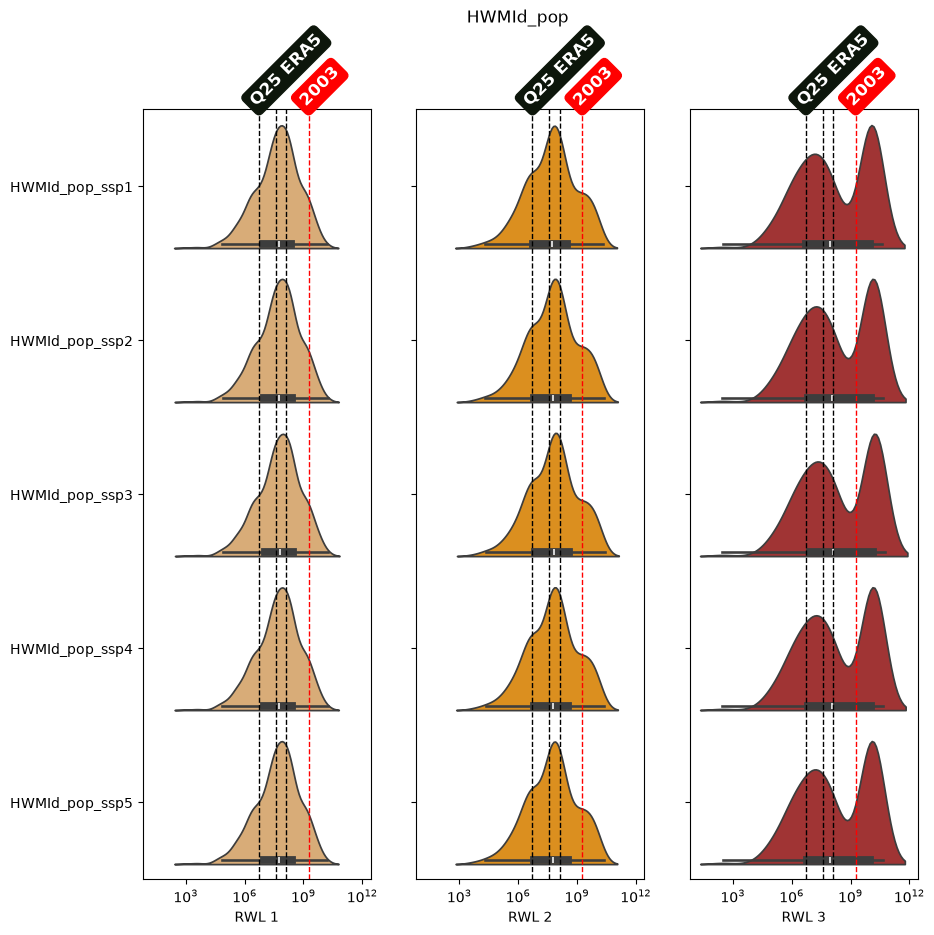

In [25]:
rwl_list = [1,2,3]
rwl_colors = ["#E8AE68", "#FA9500", "#B22222","#9D1E1E"]
labels = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']

reference_htws = pd.DataFrame(index=[0,1,2,3],columns=['label','HWMId_pop_ghs'])
ERA5_label_2003=176
for i_ref in reference_htws.index[:-1]:
    reference_htws.loc[i_ref,'label'] = f"Q{(i_ref+1)*25}"
    reference_htws.loc[i_ref,'HWMId_pop_ghs'] = df_htws[df_htws['model']=='ERA5']['HWMId_pop_ghs'].quantile((i_ref+1)*0.25)
reference_htws.loc[3,'HWMId_pop_ghs'] = df_htws[(df_htws['model']=='ERA5') & (df_htws['original_label']==ERA5_label_2003)]['HWMId_pop_ghs'].values[0]
reference_htws.loc[3,'label'] = '2003'

fig,axes = plt.subplots(1,len(rwl_list),figsize=(10,10),sharex=True,sharey=True)
for i,rwl in enumerate(rwl_list):
    df_rwl = df_htws_BC_results[df_htws_BC_results[f'Period RWL {rwl}']]
    df_rwl = df_rwl[['HWMId_pop_ssp1','HWMId_pop_ssp2','HWMId_pop_ssp3','HWMId_pop_ssp4','HWMId_pop_ssp5']]
    # Filter NaNs out
    df_rwl = df_rwl[~pd.isnull(df_rwl['HWMId_pop_ssp1'])]
    df_rwl = df_rwl[df_rwl['HWMId_pop_ssp1']>0]
    df_rwl = df_rwl.astype(float)
    print(len(df_rwl))
    ax = axes[i]
    #ax.violinplot(df_rwl,facecolor=mpl.colors.to_rgba(rwl_colors[rwl-1],alpha=0.65),linecolor=rwl_colors[rwl-1])
    sns.violinplot(df_rwl,color=rwl_colors[rwl-1],ax=ax,log_scale=True,split=True,orient='h')
    #sns.histplot(df_rwl,color=rwl_colors[rwl-1],ax=ax,log_scale=True,orient='h')
    ax.set_xlabel(f'RWL {rwl}')
    ax.axvline(x=reference_htws.loc[0,'HWMId_pop_ghs'],linestyle='--',color='k',linewidth=1)
    ax.axvline(x=reference_htws.loc[1,'HWMId_pop_ghs'],linestyle='--',color='k',linewidth=1)
    ax.axvline(x=reference_htws.loc[2,'HWMId_pop_ghs'],linestyle='--',color='k',linewidth=1)
    ax.axvline(x=reference_htws.loc[3,'HWMId_pop_ghs'],linestyle='--',color='red',linewidth=1)
    #ax.annotate(text='2003',color='red')
    ax.text(
            x=reference_htws.loc[3,'HWMId_pop_ghs'],
            y=-0.5,
            s='2003',
            ha="left",
            va="bottom",
            fontsize=12,#self._config["reference_event_label_fontsize"],
            fontweight="bold",
            color="white",
            rotation=45,#self._config["reference_event_label_rotation"],
            zorder=3.1,
            bbox=dict(
                facecolor='red',
                edgecolor='red',
                alpha=1,
                linewidth=1,
                boxstyle="round",
            ),
            rotation_mode="anchor",
        )
    ax.text(
            x=reference_htws.loc[0,'HWMId_pop_ghs'],
            y=-0.5,
            s='Q25 ERA5',
            ha="left",
            va="bottom",
            fontsize=12,#self._config["reference_event_label_fontsize"],
            fontweight="bold",
            color="white",
            rotation=45,#self._config["reference_event_label_rotation"],
            zorder=3.1,
            bbox=dict(
                facecolor='#0D160B',
                edgecolor='#0D160B',
                alpha=1,
                linewidth=1,
                boxstyle="round",
            ),
            rotation_mode="anchor",
        )
    #set_axis_style(ax, labels)
fig.suptitle('HWMId_pop')
fig.savefig(join(datadir,'figs','RWL_and_SSP_lines_HWMId_pop.pdf'),dpi=1200,bbox_inches='tight')
fig.savefig(join(datadir,'figs','RWL_and_SSP_lines_HWMId_pop.png'),bbox_inches='tight')
plt.show()

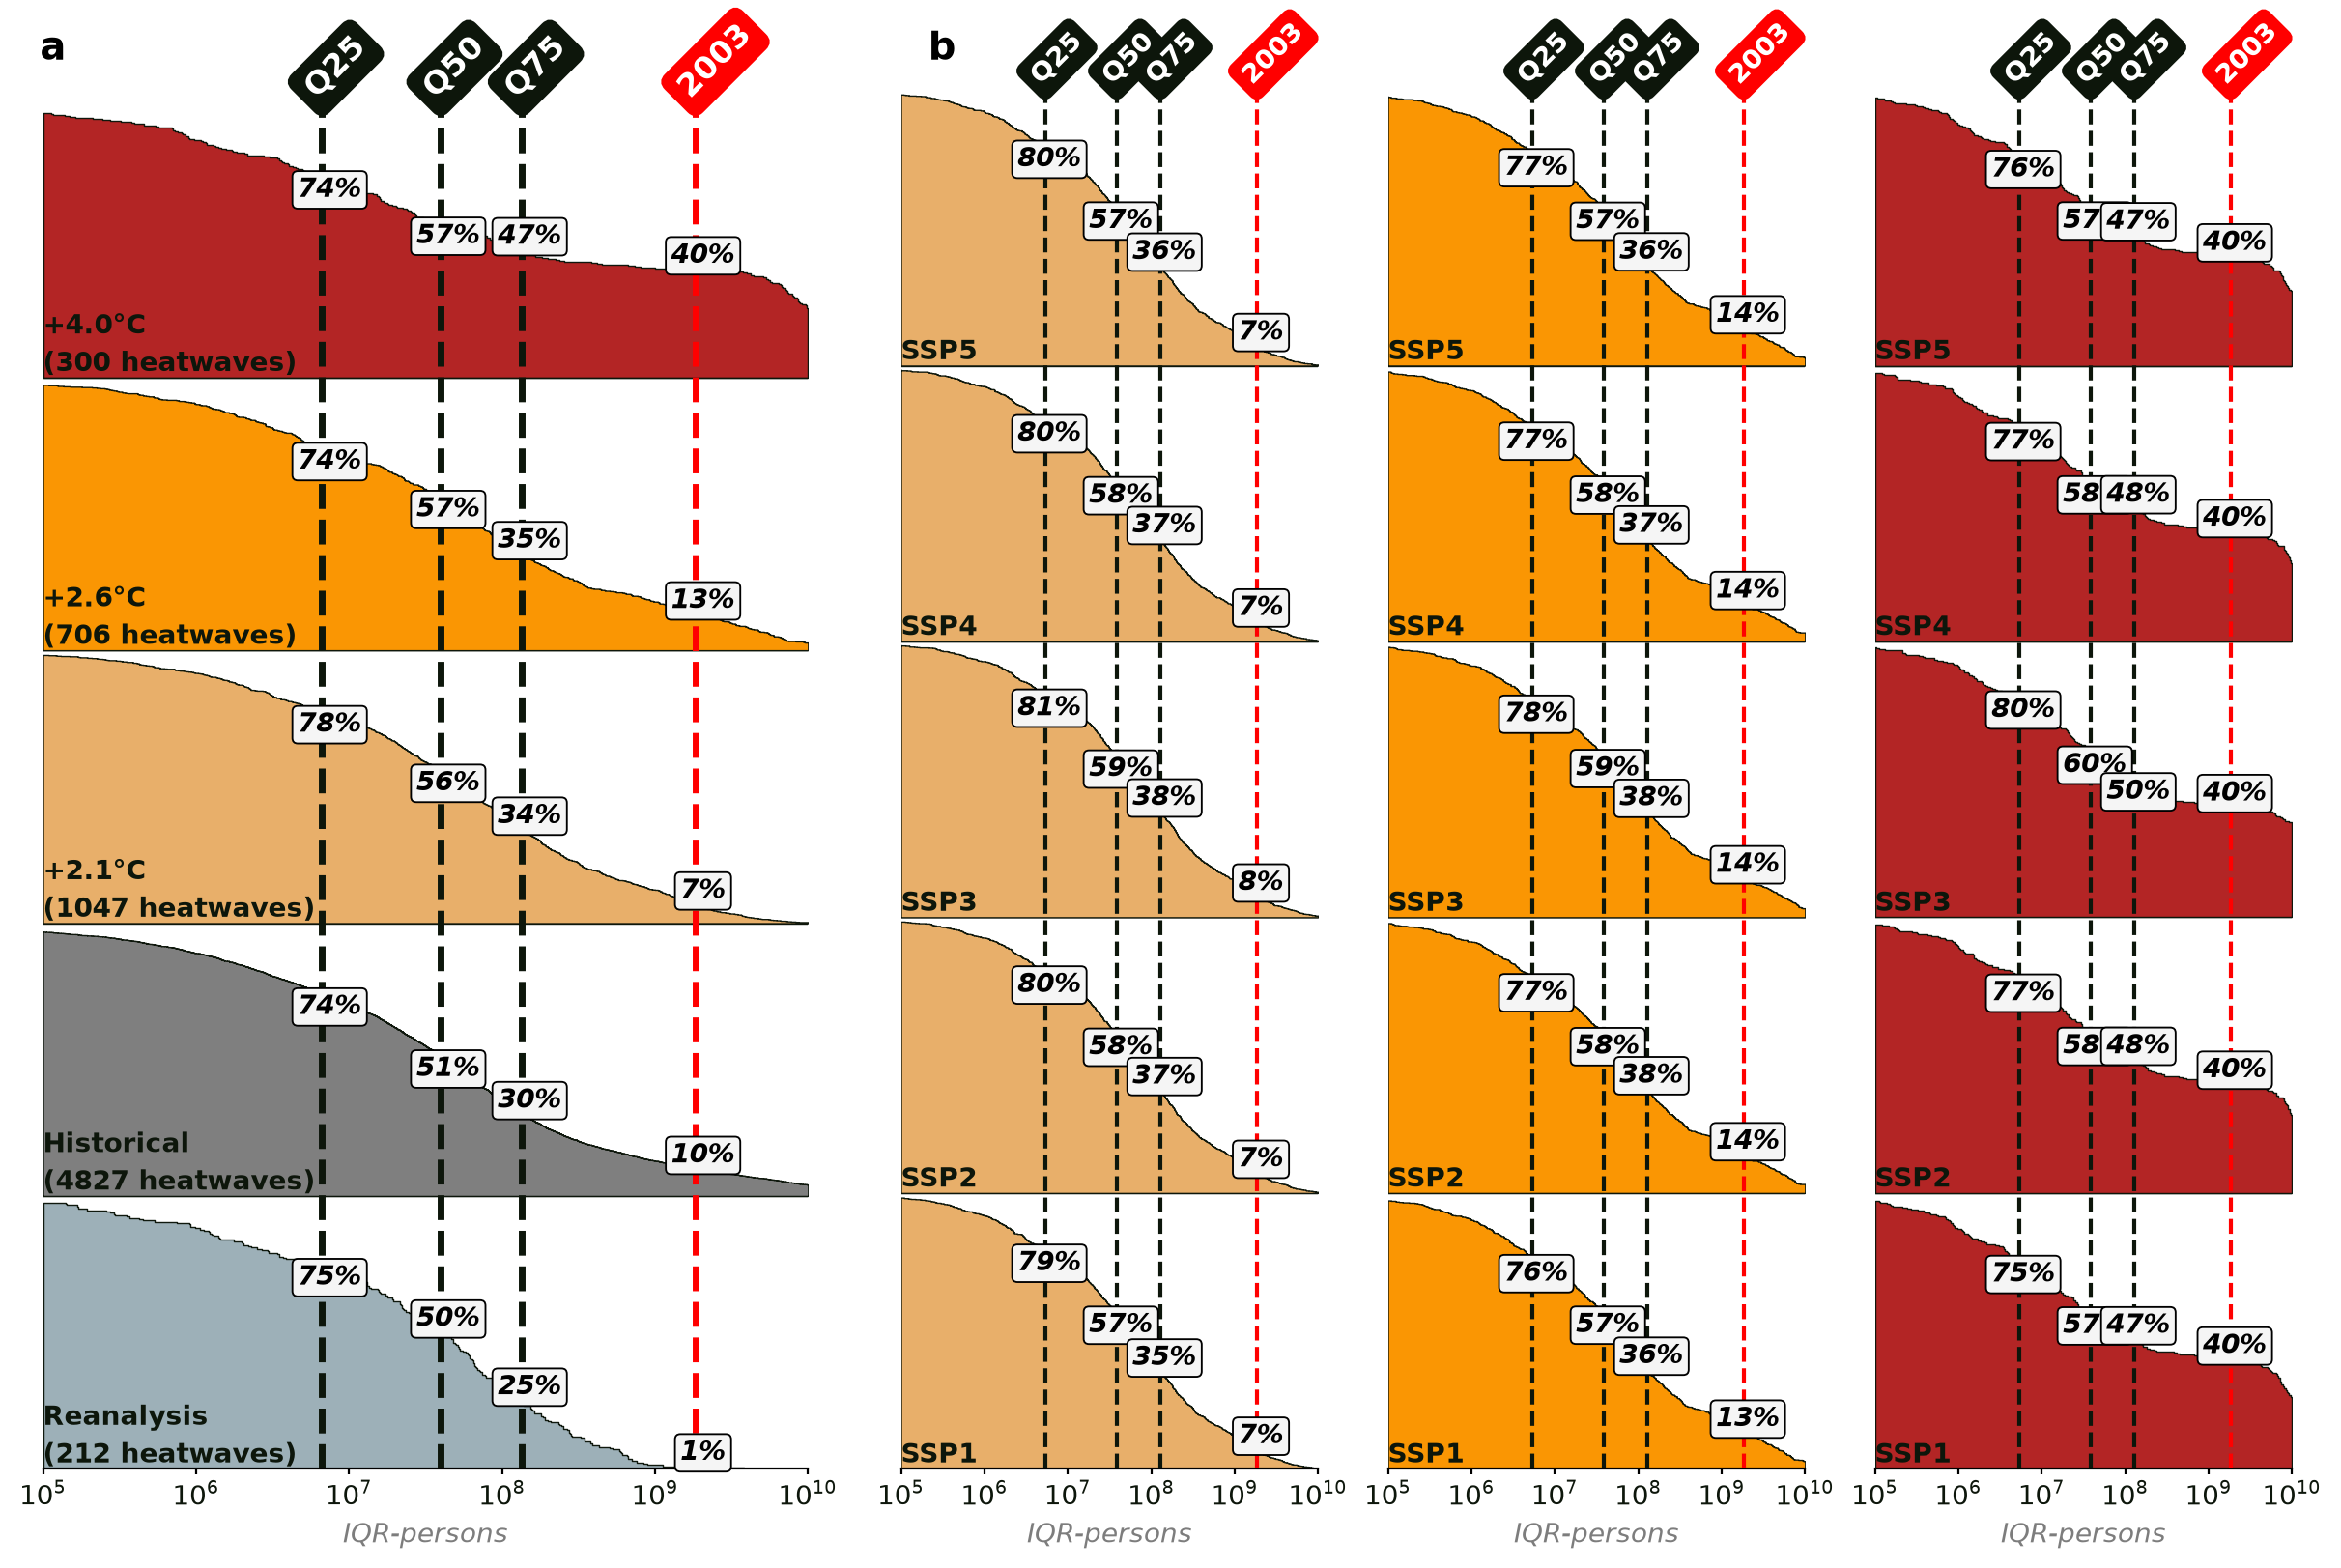

In [26]:
log_indices = ['Spatial extent','Accumulated area','HWMId_sum','Exposed_population_ghs','HWMId_pop_ghs','Exposed_population_ssp1','HWMId_pop_ssp1','Exposed_population_ssp2','HWMId_pop_ssp2',
    'Exposed_population_ssp3','HWMId_pop_ssp3','Exposed_population_ssp4','HWMId_pop_ssp4','Exposed_population_ssp5','HWMId_pop_ssp5','Exposed_population_ssp1_all_period','HWMId_pop_ssp1_all_period','Exposed_population_ssp2_all_period','HWMId_pop_ssp2_all_period',
    'Exposed_population_ssp3_all_period','HWMId_pop_ssp3_all_period','Exposed_population_ssp4_all_period','HWMId_pop_ssp4_all_period','Exposed_population_ssp5_all_period','HWMId_pop_ssp5_all_period','Distance']
regional_warming_levels_list=[2.1,2.6,4.0,5.1]
RWLs_to_plot = [0,1,2]
ERA5_label_2003=176
def mylog(x):
    if x>0:
        res = np.log10(x)
    else:
        res = np.nan
    return res

df_RWL_plot = pd.concat([df_htws_BC_results,df_ERA5])
df_global_htws = df_RWL_plot

fig = plt.figure(constrained_layout=True,figsize=(12,8))
subfigs = fig.subfigures(1, 2,width_ratios=[1,1.75])
subfig = subfigs.flat[0]
ax = subfig.subplots(1, 1)
bounds = (5,10)
index='HWMId_pop_ssp1_all_period'
# Cast objet type to numeric type
df_global_htws[index] = df_global_htws[index].astype(float)
if index in log_indices:
    df_global_htws[index] = df_global_htws[index].map(mylog)

reference_htws = pd.DataFrame(index=[0,1,2,3],columns=['label',index])
for i_ref in reference_htws.index[:-1]:
    reference_htws.loc[i_ref,'label'] = f"Q{(i_ref+1)*25}"
    reference_htws.loc[i_ref,index] = df_global_htws[df_global_htws['model']=='ERA5'][index].quantile((i_ref+1)*0.25)
reference_htws.loc[3,index] = df_global_htws[(df_global_htws['model']=='ERA5') & (df_global_htws['original_label']==ERA5_label_2003)][index].values[0]
reference_htws.loc[3,'label'] = '2003'
# Plot figure
plotter = PeriodDistributionPlotter(ax=ax)
# Customize the visualization settings --> see documentation for all options
plotter.update_config(
    display_mode="cumulative_histogram", kde_height_scale=1,
    reference_event_label_fontsize="medium",  # Font size for reference event labels
    reference_event_label_bbox_linewidth=1,  # Border width for reference event label boxes
)
plotted_data = df_global_htws[pd.isnull(df_global_htws[index])==False]
plotter.plot(
    data=plotted_data,#.query("sdi == 'SPI' and aggregation == 3"),
    variable=index,
    periods_columns_labels={
        "Reanalysis": f"Reanalysis\n({len(plotted_data[plotted_data['Reanalysis']])} heatwaves)",
        "Historical": f"Historical\n({len(plotted_data[plotted_data['Historical']])} heatwaves)",
        f"Period RWL {RWLs_to_plot[0]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[0]]}°C\n({len(plotted_data[plotted_data[f"Period RWL {RWLs_to_plot[0]+1}"]])} heatwaves)",#"+1.5°C",f"Period RWL {RWLs_to_plot[0]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[0]]}°C",#"+1.5°C",
        f"Period RWL {RWLs_to_plot[1]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[1]]}°C\n({len(plotted_data[plotted_data[f"Period RWL {RWLs_to_plot[1]+1}"]])} heatwaves)",#"+2°C",
        f"Period RWL {RWLs_to_plot[2]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[2]]}°C\n({len(plotted_data[plotted_data[f"Period RWL {RWLs_to_plot[2]+1}"]])} heatwaves)",#"+3°C",
    },
    #reference_events=None,
    reference_events=reference_htws,#.query("sdi == 'SPI' and aggregation == 3"),
    #cut_kdes=False,  # Whether to cut the KDEs at the minimum / maximum values of the events at each period
    bounds=bounds,
)
# Accessing the figure object to modify it further if needed
subfig.text(
        0.05,
        0.975,
        'a',
        ha="center",
        va="center",
        fontsize="large",
        fontweight="bold",
    )

if index in log_indices:
    labels = np.array(ax.get_xticks().tolist(), dtype=np.float64)
    new_ticks = np.unique([int(i) for i in labels])
    new_labels = [r'$10^{%.0f}$' % (new_ticks[i]) for i in range(len(new_ticks))]
    ax.set_xticks(new_ticks)
    ax.set_xticklabels(new_labels)

fig.set_facecolor('white')
ax.set_facecolor('white')


rwl_list = [1,2,3]
rwl_colors = ["#E8AE68", "#FA9500", "#B22222","#9D1E1E"]
labels = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']

reference_htws = pd.DataFrame(index=[0,1,2,3],columns=['label','HWMId_pop'])
ERA5_label_2003=176
for i_ref in reference_htws.index[:-1]:
    reference_htws.loc[i_ref,'label'] = f"Q{(i_ref+1)*25}"
    reference_htws.loc[i_ref,'HWMId_pop'] = df_ERA5['HWMId_pop_ghs'].quantile((i_ref+1)*0.25)
reference_htws.loc[3,'HWMId_pop'] = df_ERA5[df_ERA5['original_label']==ERA5_label_2003]['HWMId_pop_ghs'].values[0]
reference_htws.loc[3,'label'] = '2003'
reference_htws['HWMId_pop'] = reference_htws['HWMId_pop'].map(mylog)

outerind = 1
subfig = subfigs.flat[1]
axs = subfig.subplots(1, 3,sharex=True,sharey=True)

for i,rwl in enumerate(rwl_list):
    ax = axs.flat[i]
    df_rwl = df_htws_BC_results[df_htws_BC_results[f'Period RWL {rwl}']]
    plotted_df = pd.DataFrame(index=range(len(df_rwl)*5),columns=['HWMId_pop','SSP1','SSP2','SSP3','SSP4','SSP5'])
    for k in range(5):
        plotted_df[f'SSP{k+1}'] = False
        plotted_df.iloc[k*len(df_rwl):(k+1)*len(df_rwl),0] = df_rwl[f'HWMId_pop_ssp{k+1}']
        plotted_df.iloc[k*len(df_rwl):(k+1)*len(df_rwl),k+1] = True
    # Filter NaNs out
    plotted_df['HWMId_pop'] = plotted_df['HWMId_pop'].astype(float)
    plotted_df['HWMId_pop'] = plotted_df['HWMId_pop'].map(mylog)
    plotter = p_V2.PeriodDistributionPlotter(ax=ax, language="en")
    # Customize the visualization settings --> see documentation for all options
    plotter.update_config(
        display_mode="cumulative_histogram", kde_height_scale=1,# Reference Events Configuration
        reference_event_linewidth=1.5,  # Line width for reference event vertical lines
        reference_event_label_fontsize="small",  # Font size for reference event labels
        reference_event_label_rotation=45,  # Rotation angle for reference event labels
        reference_event_label_bbox_linewidth=1,  # Border width for reference event label boxes
        #ColorScheme = [rwl_colors[rwl-1]]*8,
    )
    plotter.plot(
        data=plotted_df,
        variable='HWMId_pop',
        periods_columns_labels={
            "SSP1": "SSP1",
            "SSP2": "SSP2",
            "SSP3": "SSP3",
            "SSP4": "SSP4",
            "SSP5": "SSP5", 
        },
        reference_events=reference_htws,
        cut_kdes=False,
        bounds=bounds,
        my_color=rwl_colors[rwl-1],
    )
    ax.set_xlim([5,10])
    labels = np.array(ax.get_xticks().tolist(), dtype=np.float64)
    new_ticks = np.unique([int(i) for i in labels])
    new_labels = [r'$10^{%.0f}$' % (new_ticks[i]) for i in range(len(new_ticks))]
    ax.set_xticks(new_ticks)
    ax.set_xticklabels(new_labels)
    ax.set_xlim([5,10])
subfig.text(
        0.05,
        0.975,
        'b',
        ha="center",
        va="center",
        fontsize="large",
        fontweight="bold",
    )
fig.savefig(join(datadir,'figs','RWL_and_SSP_HWMId_pop_1fig.pdf'),dpi=1200,bbox_inches='tight')
fig.savefig(join(datadir,'figs','RWL_and_SSP_HWMId_pop_1fig.png'),bbox_inches='tight')
plt.show()

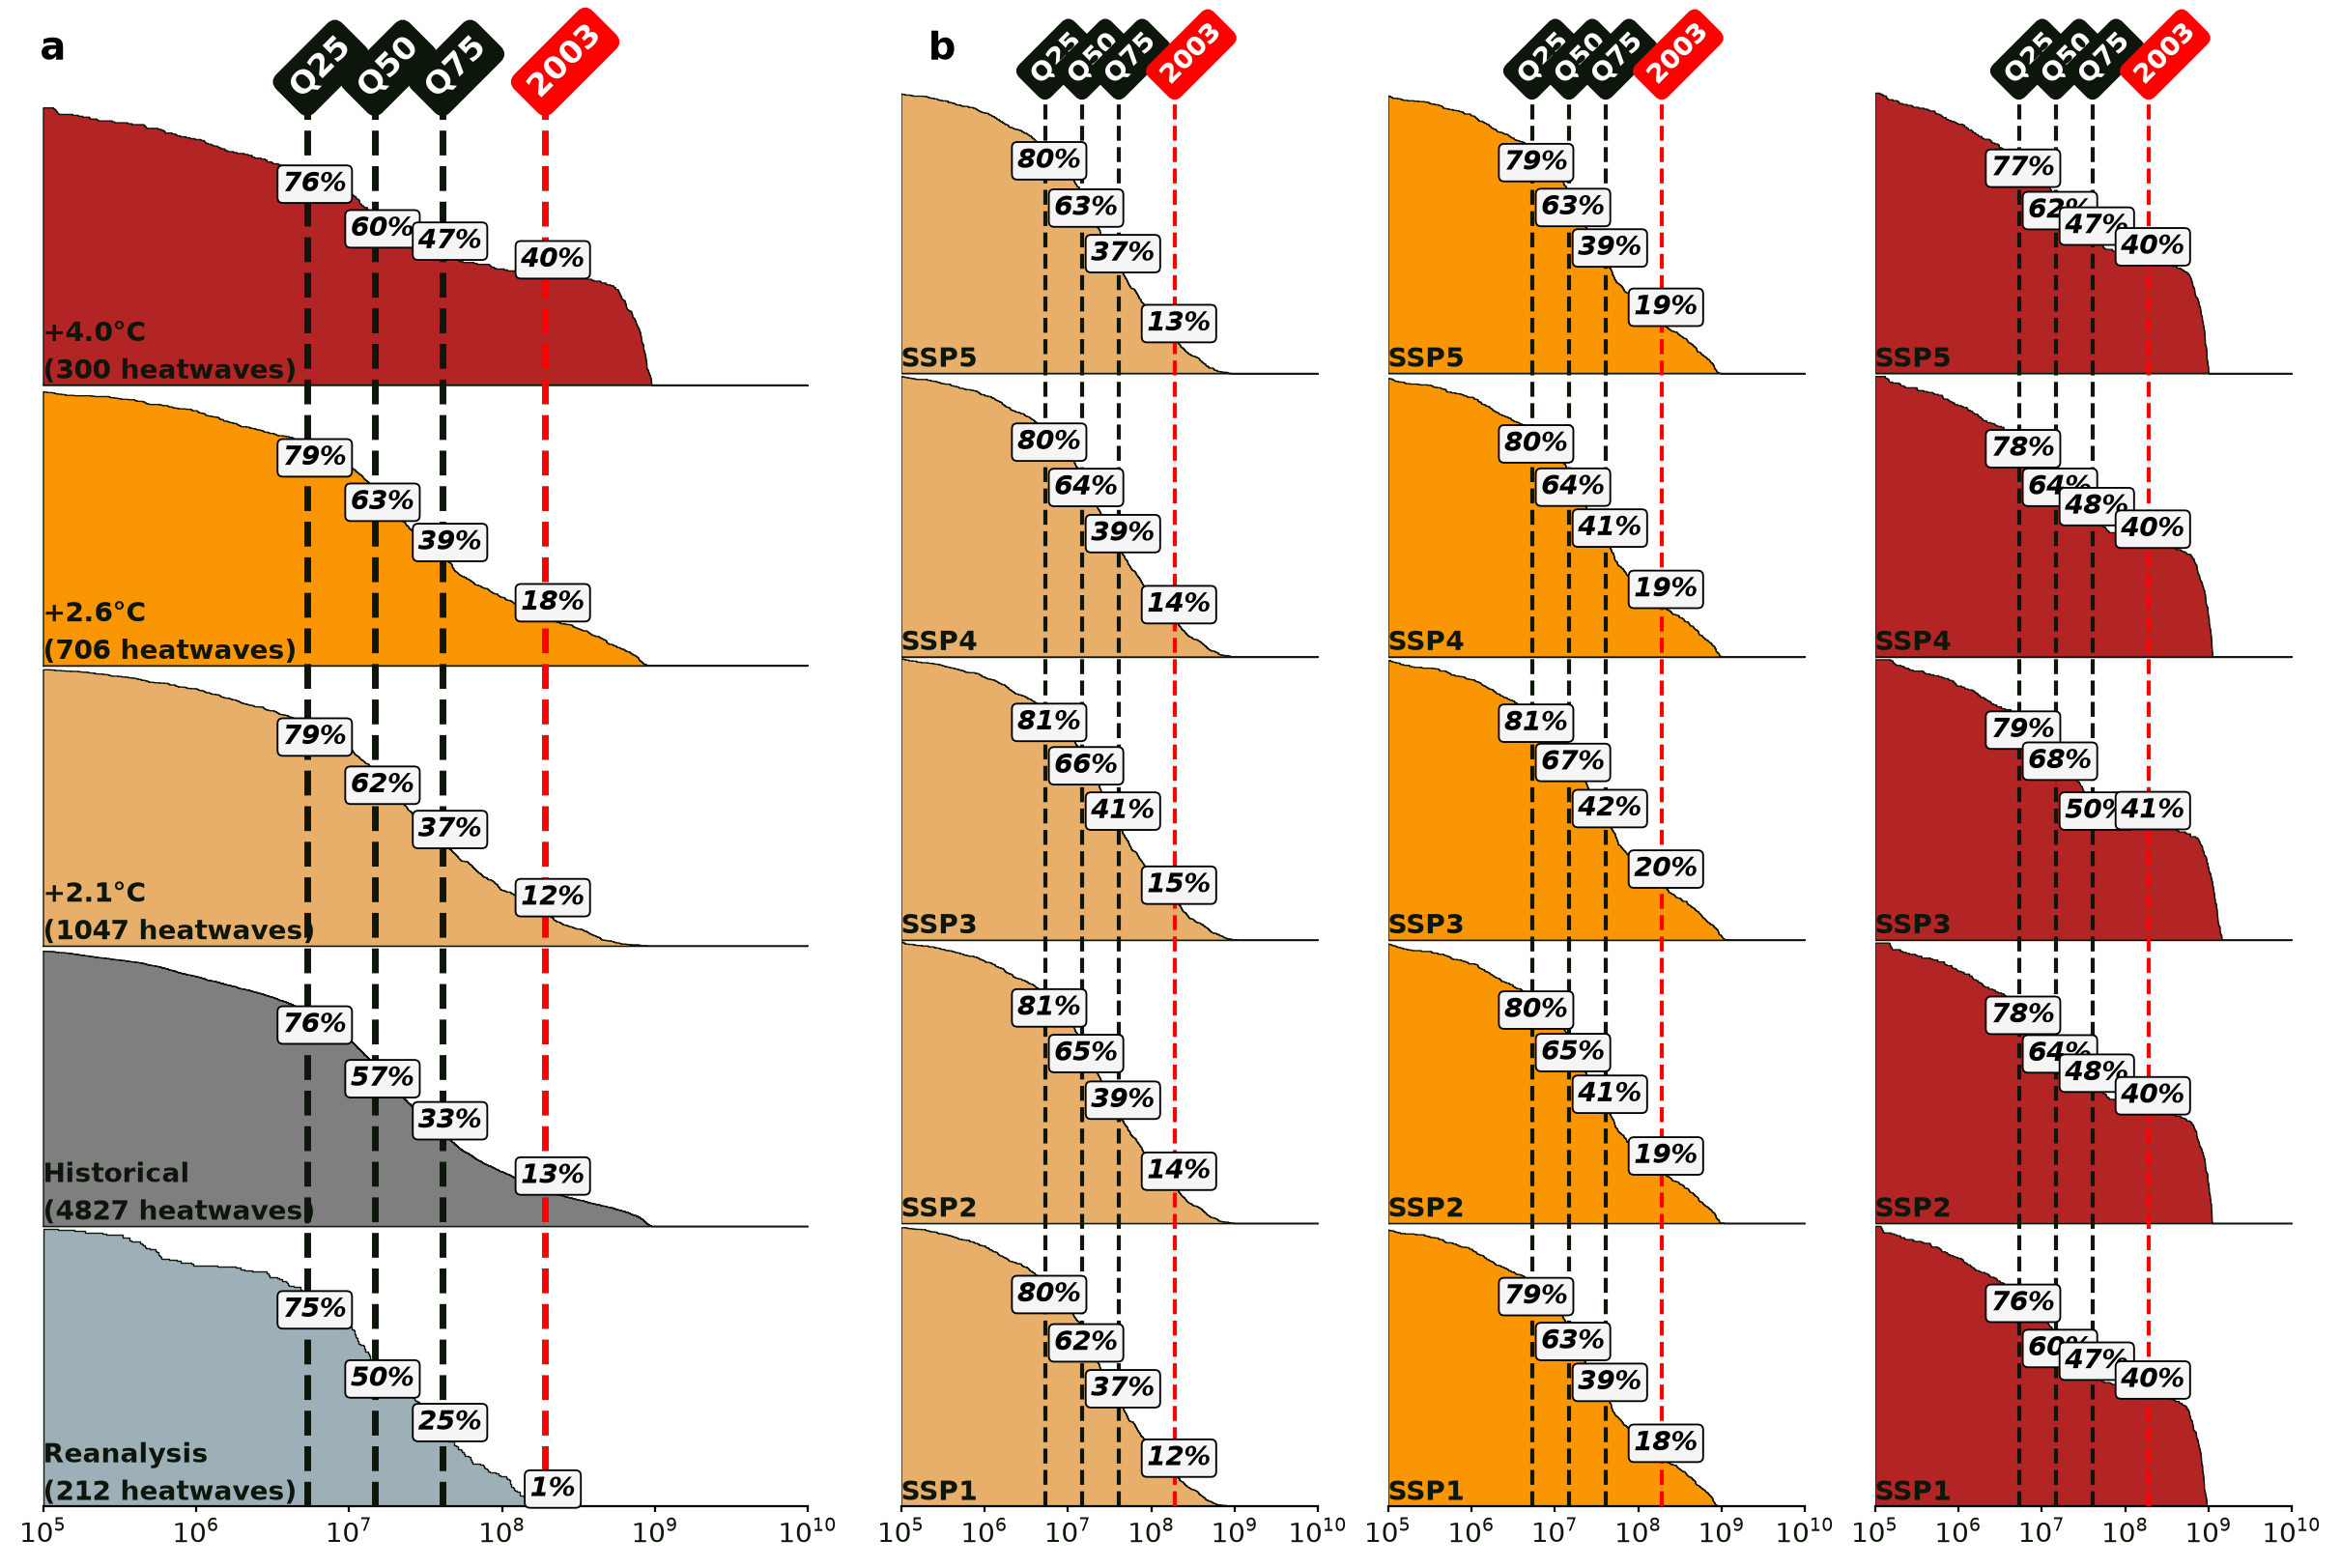

In [28]:
log_indices = ['Spatial extent','Accumulated area','HWMId_sum','Exposed_population_ghs','HWMId_pop_ghs','Exposed_population_ssp1','HWMId_pop_ssp1','Exposed_population_ssp2','HWMId_pop_ssp2',
    'Exposed_population_ssp3','HWMId_pop_ssp3','Exposed_population_ssp4','HWMId_pop_ssp4','Exposed_population_ssp5','HWMId_pop_ssp5','Exposed_population_ssp1_all_period','HWMId_pop_ssp1_all_period','Exposed_population_ssp2_all_period','HWMId_pop_ssp2_all_period',
    'Exposed_population_ssp3_all_period','HWMId_pop_ssp3_all_period','Exposed_population_ssp4_all_period','HWMId_pop_ssp4_all_period','Exposed_population_ssp5_all_period','HWMId_pop_ssp5_all_period','Distance']
regional_warming_levels_list=[2.1,2.6,4.0,5.1]
RWLs_to_plot = [0,1,2]
ERA5_label_2003=176
def mylog(x):
    if x>0:
        res = np.log10(x)
    else:
        res = np.nan
    return res

df_RWL_plot = pd.concat([df_htws_BC_results,df_ERA5])
df_global_htws = df_RWL_plot

fig = plt.figure(constrained_layout=True,figsize=(12,8))
subfigs = fig.subfigures(1, 2,width_ratios=[1,1.75])
subfig = subfigs.flat[0]
ax = subfig.subplots(1, 1)
bounds = (5,10)
index='Exposed_population_ssp1_all_period'
# Cast objet type to numeric type
df_global_htws[index] = df_global_htws[index].astype(float)
if index in log_indices:
    df_global_htws[index] = df_global_htws[index].map(mylog)

reference_htws = pd.DataFrame(index=[0,1,2,3],columns=['label',index])
for i_ref in reference_htws.index[:-1]:
    reference_htws.loc[i_ref,'label'] = f"Q{(i_ref+1)*25}"
    reference_htws.loc[i_ref,index] = df_global_htws[df_global_htws['model']=='ERA5'][index].quantile((i_ref+1)*0.25)
reference_htws.loc[3,index] = df_global_htws[(df_global_htws['model']=='ERA5') & (df_global_htws['original_label']==ERA5_label_2003)][index].values[0]
reference_htws.loc[3,'label'] = '2003'
# Plot figure
plotter = PeriodDistributionPlotter(ax=ax)
# Customize the visualization settings --> see documentation for all options
plotter.update_config(
    display_mode="cumulative_histogram", kde_height_scale=1,
    reference_event_label_fontsize="medium",  # Font size for reference event labels
    reference_event_label_bbox_linewidth=1,  # Border width for reference event label boxes
)
plotted_data = df_global_htws[pd.isnull(df_global_htws[index])==False]
plotter.plot(
    data=plotted_data,#.query("sdi == 'SPI' and aggregation == 3"),
    variable=index,
    periods_columns_labels={
        "Reanalysis": f"Reanalysis\n(212 heatwaves)",
        "Historical": f"Historical\n(4827 heatwaves)",
        f"Period RWL {RWLs_to_plot[0]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[0]]}°C\n(1047 heatwaves)",#"+1.5°C",f"Period RWL {RWLs_to_plot[0]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[0]]}°C",#"+1.5°C",
        f"Period RWL {RWLs_to_plot[1]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[1]]}°C\n(706 heatwaves)",#"+2°C",
        f"Period RWL {RWLs_to_plot[2]+1}": f"+{regional_warming_levels_list[RWLs_to_plot[2]]}°C\n(300 heatwaves)",#"+3°C",
    },
    #reference_events=None,
    reference_events=reference_htws,#.query("sdi == 'SPI' and aggregation == 3"),
    #cut_kdes=False,  # Whether to cut the KDEs at the minimum / maximum values of the events at each period
    bounds=bounds,
)
# Accessing the figure object to modify it further if needed
subfig.text(
        0.05,
        0.975,
        'a',
        ha="center",
        va="center",
        fontsize="large",
        fontweight="bold",
    )

if index in log_indices:
    labels = np.array(ax.get_xticks().tolist(), dtype=np.float64)
    new_ticks = np.unique([int(i) for i in labels])
    new_labels = [r'$10^{%.0f}$' % (new_ticks[i]) for i in range(len(new_ticks))]
    ax.set_xticks(new_ticks)
    ax.set_xticklabels(new_labels)

fig.set_facecolor('white')
ax.set_facecolor('white')


rwl_list = [1,2,3]
rwl_colors = ["#E8AE68", "#FA9500", "#B22222","#9D1E1E"]
labels = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']

reference_htws = pd.DataFrame(index=[0,1,2,3],columns=['label','Exposed_population'])
ERA5_label_2003=176
for i_ref in reference_htws.index[:-1]:
    reference_htws.loc[i_ref,'label'] = f"Q{(i_ref+1)*25}"
    reference_htws.loc[i_ref,'Exposed_population'] = df_ERA5['Exposed_population_ghs'].quantile((i_ref+1)*0.25)
reference_htws.loc[3,'Exposed_population'] = df_ERA5[df_ERA5['original_label']==ERA5_label_2003]['Exposed_population_ghs'].values[0]
reference_htws.loc[3,'label'] = '2003'
reference_htws['Exposed_population'] = reference_htws['Exposed_population'].map(mylog)

outerind = 1
subfig = subfigs.flat[1]
axs = subfig.subplots(1, 3,sharex=True,sharey=True)

for i,rwl in enumerate(rwl_list):
    ax = axs.flat[i]
    df_rwl = df_htws_BC_results[df_htws_BC_results[f'Period RWL {rwl}']]
    plotted_df = pd.DataFrame(index=range(len(df_rwl)*5),columns=['Exposed_population','SSP1','SSP2','SSP3','SSP4','SSP5'])
    for k in range(5):
        plotted_df[f'SSP{k+1}'] = False
        plotted_df.iloc[k*len(df_rwl):(k+1)*len(df_rwl),0] = df_rwl[f'Exposed_population_ssp{k+1}']
        plotted_df.iloc[k*len(df_rwl):(k+1)*len(df_rwl),k+1] = True
    # Filter NaNs out
    plotted_df['Exposed_population'] = plotted_df['Exposed_population'].astype(float)
    plotted_df['Exposed_population'] = plotted_df['Exposed_population'].map(mylog)
    plotter = p_V2.PeriodDistributionPlotter(ax=ax, language="en")
    # Customize the visualization settings --> see documentation for all options
    plotter.update_config(
        display_mode="cumulative_histogram", kde_height_scale=1,# Reference Events Configuration
        reference_event_linewidth=1.5,  # Line width for reference event vertical lines
        reference_event_label_fontsize="small",  # Font size for reference event labels
        reference_event_label_rotation=45,  # Rotation angle for reference event labels
        reference_event_label_bbox_linewidth=1,  # Border width for reference event label boxes
        #ColorScheme = [rwl_colors[rwl-1]]*8,
    )
    plotter.plot(
        data=plotted_df,
        variable='Exposed_population',
        periods_columns_labels={
            "SSP1": "SSP1",
            "SSP2": "SSP2",
            "SSP3": "SSP3",
            "SSP4": "SSP4",
            "SSP5": "SSP5", 
        },
        reference_events=reference_htws,
        cut_kdes=False,
        bounds=bounds,
        my_color=rwl_colors[rwl-1],
    )
    ax.set_xlim([5,10])
    labels = np.array(ax.get_xticks().tolist(), dtype=np.float64)
    new_ticks = np.unique([int(i) for i in labels])
    new_labels = [r'$10^{%.0f}$' % (new_ticks[i]) for i in range(len(new_ticks))]
    ax.set_xticks(new_ticks)
    ax.set_xticklabels(new_labels)
    ax.set_xlim([5,10])
subfig.text(
        0.05,
        0.975,
        'b',
        ha="center",
        va="center",
        fontsize="large",
        fontweight="bold",
    )
fig.savefig(join(datadir,'figs','RWL_and_SSP_Exposed_population_1fig.pdf'),dpi=1200,bbox_inches='tight')
fig.savefig(join(datadir,'figs','RWL_and_SSP_Exposed_population_1fig.png'),bbox_inches='tight')
plt.show()